# Factor Graphs

A **factor graph** is the natural generalization of the pose-graph data structure used in [pose_graph_slam.ipynb](pose_graph_slam.ipynb). It supports heterogeneous variables (poses, landmarks, IMU bias, calibration, ...) and heterogeneous factor types (between, prior, projection, range, bearing, ...) — but the optimization machinery is exactly the [nonlinear-least-squares backend](nonlinear_least_squares.ipynb) we already studied. The pose representation, wrap function, and log map are inherited from [lie_groups_se2.ipynb](lie_groups_se2.ipynb).

What this notebook covers:

1. **Bipartite graph view** — variables and factors as separate node types; how the MAP problem reads off the graph.
2. **Information form** ($\Lambda = \Sigma^{-1}$) — why elimination is natural in information form.
3. **Notation cheat sheet** — $\oplus, \ominus, \boxplus, \boxminus, \Lambda, \eta, \Omega$.
4. **A 5-pose running example** that we will reuse in every section below, with real numerical values from the INTEL dataset.
5. **Where the per-edge information $\Omega$ comes from** — datasheets, calibration, propagation, residual analysis.
6. **Building $\Lambda$ from factors** — the assembly equation $\Delta\Lambda = J^\top\Omega J$.
7. **Marginalization & the Schur complement** — symbolically and with real numbers from the running example.
8. **Provenance of $\Lambda$ blocks** — assembly vs Schur, and why iSAM2 keeps both.
9. **Variable elimination** — what it physically means, why it produces fill-in, and how it relates to Cholesky / QR.
10. **Solving $\Delta\chi$ on the tree** — back-substitution from root to leaves.
11. **Square-root form & QR factorization** — whiten the Jacobians, do QR on $\tilde J$, get the same $R$ as Cholesky on $\Lambda$ but in a form iSAM2 can update incrementally.
12. **Cliques & the Bayes tree** — the data structure that records each elimination step.
13. **Elimination ordering** (MMD, COLAMD, nested dissection) — why ordering matters for cost, not for correctness.
14. **iSAM2 — batch and online** — full step-by-step algorithms.
15. **Fixed-lag smoothing** — what happens when a loop closure reaches outside the window, and why production systems run two back-ends.
16. **GTSAM Python code** — batch LM and incremental iSAM2 on the INTEL dataset, plus a small 10-pose toy that shows per-step iSAM2 updates.

---

## 1. From pose graphs to factor graphs

A **pose graph** has one variable type (a pose $X_i \in SE(2)$ or $SE(3)$) and one factor type (a relative-pose constraint $z_{ij}$ between two poses). That uniformity is convenient but it is also a restriction.

Real SLAM problems involve more than poses:

* **Landmarks** — 3D points reconstructed from camera observations.
* **IMU biases** — slowly varying gyro / accelerometer offsets.
* **Calibration parameters** — extrinsics between sensors, camera intrinsics.
* **Velocity** — for inertial preintegration factors.

And more than between-pose constraints:

* **Prior factors** — a unary measurement on a single variable (GPS, the gauge anchor $X_0$).
* **Projection factors** — a 2D pixel observation of a 3D landmark from a camera pose.
* **Range / bearing factors** — distance or angle from a pose to a landmark.
* **IMU preintegration factors** — multi-variable factors connecting two poses, two velocities, and two biases.

A **factor graph** models all of this in one bipartite graph:

* **Variable nodes** $\theta_i$ — the unknowns we want to estimate.
* **Factor nodes** $f_k$ — each factor $f_k(\theta_{S_k})$ is a measurement-induced cost depending on the *subset* $S_k$ of variables it touches.

Edges connect each factor to the variables it touches. There are no factor–factor edges and no variable–variable edges.

> **A pose graph is a factor graph where every variable is a pose and every factor connects exactly two poses.**

---

## 2. Variables, factors, and the MAP problem

The MAP estimate is the same nonlinear-least-squares minimization we already wrote down in [§3 of nonlinear_least_squares.ipynb](nonlinear_least_squares.ipynb), just written in factor-graph notation:

$$
\hat\theta \;=\; \arg\min_{\theta}\; \sum_{k} \tfrac12\, \big\| f_k(\theta_{S_k}) \big\|^2_{\Omega_k}
\;=\; \arg\min_{\theta}\; \sum_{k} \tfrac12\, f_k(\theta_{S_k})^T\, \Omega_k\, f_k(\theta_{S_k}).
$$

* $\theta = (\theta_1, \dots, \theta_n)$ — concatenation of all variables (poses, landmarks, biases, …).
* $f_k$ — residual of factor $k$, depending only on the local subset $\theta_{S_k}$.
* $\Omega_k = \Sigma_k^{-1}$ — information matrix of the measurement noise (see [§1 of nonlinear_least_squares.ipynb](nonlinear_least_squares.ipynb)).

For pose-graph SLAM specifically, each between-pose factor $f_{ij}$ has the form

$$
f_{ij}(x_i, x_j) \;=\; \bar z_{ij} \,\ominus\, h_{ij}(x_i, x_j), \qquad
h_{ij}(x_i, x_j) \;=\; \begin{pmatrix} R(\theta_i)^\top (p_j - p_i) \\ \theta_j \ominus \theta_i \end{pmatrix},
$$

with $\bar z_{ij}$ the measurement, $h_{ij}$ the prediction, and $\ominus$ the angle-aware difference (defined in §3.5 below). This is exactly the `err_pos_x, err_pos_y, err_theta` triple from your [pose_graph_slam.ipynb](pose_graph_slam.ipynb) notebook.

Because each $f_k$ is sparse in $\theta$ (it only touches its $S_k$ variables), the Hessian

$$
H \;=\; \sum_k J_k^T \Omega_k J_k
$$

is **block-sparse**: a block $H_{ij}$ is non-zero only when some factor connects variable $i$ to variable $j$. The graph structure of the factor graph is exactly the sparsity pattern of $H$ — that's why "graph" is the right abstraction.

---

## 3. Information form: covariance $\Sigma$ vs information $\Lambda$

For Gaussian distributions there are two equivalent parameterizations:

| | covariance form | information form |
|---|---|---|
| parameter | mean $\mu$, covariance $\Sigma$ | information vector $\eta$, information matrix $\Lambda = \Sigma^{-1}$ |
| density | $p(x) \propto \exp\!\big(-\tfrac12 (x-\mu)^T \Sigma^{-1} (x-\mu)\big)$ | $p(x) \propto \exp\!\big(-\tfrac12 x^T \Lambda x + \eta^T x\big)$ |
| zero off-diagonal $\Leftrightarrow$ | uncorrelated | conditionally independent (given the rest) |
| factors combine by | (no simple rule) | **addition** of $\Lambda$ blocks and $\eta$ blocks |
| marginalization | trivial — just delete rows/columns | requires Schur complement |
| conditioning | requires Schur complement | trivial — just delete rows/columns |

For factor graphs the information form is the right one because:

1. **Factors compose additively in $\Lambda$.** Each factor contributes $J_k^T \Omega_k J_k$ to $\Lambda$; the global $\Lambda$ is just the sum. The graph and the matrix are isomorphic.
2. **Sparsity in $\Lambda$ matches conditional independence in the graph.** If no factor connects variable $i$ and variable $j$, then $\Lambda_{ij} = 0$ — they are conditionally independent given all the other variables.
3. **Elimination = Schur complement = block-Cholesky on $\Lambda$.** As we will see below, "removing a variable" is the same operation in all three views.

The covariance form is what you want at the *end* — for downstream uses you usually report mean and covariance per variable. Internally, the backend works in information form.

---


## 3.5. Notation cheat sheet

Five symbols quietly do most of the work in factor-graph SLAM. Pin them down once and the rest of the math reads cleanly.

### $\oplus$ — wrapped angle addition

Regular addition, then clamped to $(-\pi, \pi]$ so two angles that differ by $2\pi$ are recognized as the same rotation:

$$
\theta_1 \oplus \theta_2 \;:=\; \operatorname{wrap}(\theta_1 + \theta_2), \qquad
\operatorname{wrap}(\alpha) \;=\; ((\alpha + \pi) \bmod 2\pi) - \pi.
$$

Example: $\theta_3 = -0.099$ rad, $\Delta\theta_3 = -0.002$ rad, $\theta_3 \oplus \Delta\theta_3 = -0.101$ rad. (No wrap triggered.) But $3.10 \oplus 0.10 = 3.20 - 2\pi \approx -3.08$ — same rotation, canonical representative.

### $\ominus$ — wrapped angle subtraction

$$
\theta_1 \ominus \theta_2 \;:=\; \operatorname{wrap}(\theta_1 - \theta_2).
$$

Without wrapping, "measured $3.10$, predicted $-3.10$" would look like an error of $6.20$ rad when it's only $0.08$ rad the other way around.

### $\boxplus$ — retraction (manifold + tangent vector $\to$ manifold)

Poses live on a manifold $SE(2)$, not in $\mathbb{R}^3$. Plain $+$ would let the angle drift outside $(-\pi,\pi]$. The retraction $\boxplus$ takes a pose plus a small update vector in the tangent space and produces a new pose:

$$
x \boxplus \Delta x \;:=\; \begin{pmatrix} x + \Delta x^{(1)} \\ y + \Delta x^{(2)} \\ \theta \oplus \Delta x^{(3)} \end{pmatrix}.
$$

For $SE(3)$ the rotation part uses matrix exponentials; the *concept* is the same.

### $\boxminus$ — inverse retraction (pose - pose $\to$ tangent vector)

$$
\Delta x \;=\; x_2 \boxminus x_1.
$$

Used to compute relative-pose errors in a coordinate-free way.

### $\Lambda$ — information matrix

$$
\Lambda \;:=\; \Sigma^{-1}.
$$

A Gaussian $\mathcal{N}(\mu, \Sigma)$ can be rewritten in *information form* $\mathcal{N}^{-1}(\eta, \Lambda)$ with $\eta = \Lambda \mu$ and density

$$
p(x) \;\propto\; \exp\!\Big(-\tfrac{1}{2} x^\top \Lambda x + x^\top \eta\Big).
$$

The Gauss-Newton normal-equation matrix $H$ in $H \Delta\chi = -b$ **is** an information matrix. Your pose-graph notebook's `H` is a $\Lambda$ by another name; its `b` is $-\eta$.

### $\Omega$ — per-factor measurement information

$\Omega_k = \Sigma_{\text{meas},k}^{-1}$, the inverse of the measurement-noise covariance. It is a per-factor input (you specify it when you add the factor). The global $\Lambda$ is the *output* of summing all per-factor contributions.

### Cheat sheet

| symbol | name | meaning | example |
|---|---|---|---|
| $\oplus$ | wrapped addition | angle add, in $(-\pi,\pi]$ | $-0.099 \oplus -0.002 = -0.101$ |
| $\ominus$ | wrapped subtraction | angle subtract, in $(-\pi,\pi]$ | $3.10 \ominus -3.10 = 0.08$ |
| $\boxplus$ | retraction | manifold + tangent = manifold | $+$ for position, $\oplus$ for angle |
| $\boxminus$ | inverse retraction | pose $-$ pose = tangent | $\Delta x = x_2 \boxminus x_1$ |
| $\Lambda$ | information matrix | $\Sigma^{-1}$; sums for independent measurements | $H$ in normal equations |
| $\eta$ | information vector | $\Lambda \mu$; partner of $\Lambda$ | $-b$ in normal equations |
| $\Omega$ | measurement information | per-edge $\Sigma_{\text{meas}}^{-1}$ | $\Omega_{\text{odom}} = \mathrm{diag}(50, 50, 100)$ |

---


## 4. A running example: 5 poses with one loop closure

We use this small graph for every concept below, with **real numerical values from the [INTEL dataset](https://raw.githubusercontent.com/behnamasadi/robotic_notes/refs/heads/master/data/slam/input_INTEL_g2o.g2o)** so the arithmetic is concrete.

**Variables.** Five 2D poses $x_0, x_1, x_2, x_3, x_4 \in SE(2)$, each a triple $(x, y, \theta)$ — so the state has $5 \times 3 = 15$ scalar variables.

We use INTEL vertices 4–8 (renamed $0$–$4$) because they show real motion (forward step then a $\sim 2$ rad pivot):

| pose | $x$ | $y$ | $\theta$ |
|---|---|---|---|
| $x_0$ | $+0.641008$ | $-0.011200$ | $-0.007444$ |
| $x_1$ | $+0.696016$ | $-0.011716$ | $-0.098726$ |
| $x_2$ | $+0.700269$ | $-0.015435$ | $-0.895998$ |
| $x_3$ | $+0.693956$ | $+0.004213$ | $-1.511535$ |
| $x_4$ | $+0.699263$ | $+0.026693$ | $-2.125069$ |

**Factors.**

* Odometry chain: $f_{01},\, f_{12},\, f_{23},\, f_{34}$ (relative poses between consecutive nodes — synthesized from the absolute poses above so they're noise-free).
* Loop closure: $f_{14}$ (a sensor-detected revisit between $x_1$ and $x_4$).
* Prior on $x_0$: anchors the gauge.

**Adjacency:**

| variable | neighbors | degree |
|---|---|---|
| $x_0$ | $\{x_1\}$ | 1 |
| $x_1$ | $\{x_0,\, x_2,\, x_4\}$ | 3 |
| $x_2$ | $\{x_1,\, x_3\}$ | 2 |
| $x_3$ | $\{x_2,\, x_4\}$ | 2 |
| $x_4$ | $\{x_3,\, x_1\}$ | 2 |

**Per-edge information matrices** (typical for INTEL-like datasets):

$$
\Omega_{\text{odom}} \;=\; \Omega_{\text{loop}} \;=\; \begin{pmatrix} 50 & 0 & 0 \\ 0 & 50 & 0 \\ 0 & 0 & 100 \end{pmatrix},
\qquad
\Omega_{\text{prior}} \;=\; 10^6\, I_3.
$$

This corresponds to per-measurement standard deviations $\sigma = (0.141\text{ m}, 0.141\text{ m}, 0.100\text{ rad})$. The huge prior pins the gauge — it's the factor-graph version of the `H[0:3, 0:3] += 1e6 * I` trick from the pose-graph notebook.

**Block sparsity of the assembled $\Lambda \in \mathbb{R}^{15 \times 15}$** (each block $3\times 3$):

$$
\Lambda \;=\;
\begin{pmatrix}
\Lambda_{00} & \Lambda_{01} & 0 & 0 & 0 \\
\Lambda_{10} & \Lambda_{11} & \Lambda_{12} & 0 & \Lambda_{14} \\
0 & \Lambda_{21} & \Lambda_{22} & \Lambda_{23} & 0 \\
0 & 0 & \Lambda_{32} & \Lambda_{33} & \Lambda_{34} \\
0 & \Lambda_{41} & 0 & \Lambda_{43} & \Lambda_{44}
\end{pmatrix}
$$

Pattern in pose-block form:

```
       x0  x1  x2  x3  x4
   x0:  X   X   .   .   .
   x1:  X   X   X   .   X     ← x1 is a hub because of the loop closure
   x2:  .   X   X   X   .
   x3:  .   .   X   X   X
   x4:  .   X   .   X   X
```

The non-zero blocks correspond exactly to the factors: each $f_{ij}$ contributes $J^T \Omega J$ blocks at $(i,i), (i,j), (j,i), (j,j)$. The prior on $x_0$ adds to $\Lambda_{00}$.

We will refer to this graph throughout.

---


## 4.4. How this maps to `pose_graph_slam.ipynb`

If you came from the pose-graph notebook, you already built a global system $H\,\Delta x = -b$ from edges. The factor-graph $\Lambda$ in §4 is **literally the same matrix** — only renamed and embedded in a Bayesian framing that enables elimination and incremental updates later in this notebook. The §3.5 cheat sheet already states this in one line; here we make the correspondence explicit on the running examples.

### Symbol-for-symbol mapping

| Concept | `pose_graph_slam` (§6–§8) | `factor_graph` (§3–§4) |
|---|---|---|
| Global matrix being assembled | $H \in \mathbb{R}^{3N\times 3N}$ | $\Lambda \in \mathbb{R}^{3n\times 3n}$ |
| Global RHS vector | $b$ (in $H\,\Delta x = -b$) | $\eta$ (in $\Lambda\,\delta = \eta$), so $b = -\eta$ |
| Per-edge / per-factor information | $\Omega_{ij} = \Sigma_{ij}^{-1}$ | $\Omega_k = \Sigma_{\text{meas},k}^{-1}$ |
| Jacobian of $e$ w.r.t. $\mathbf{x}_i$ | $A_{ij} = \partial e_{ij}/\partial \mathbf{x}_i$ | $A = \partial e/\partial \mathbf{x}_i$ |
| Jacobian of $e$ w.r.t. $\mathbf{x}_j$ | $B_{ij} = \partial e_{ij}/\partial \mathbf{x}_j$ | $B = \partial e/\partial \mathbf{x}_j$ |
| Sparse edge Jacobian | $J_{ij} = [\,A_{ij}\;B_{ij}\,]$ (zero-padded) | $J = [\,A\;B\,]$ |
| Diagonal block update | $H_{ii} \mathrel{+}= A^\top \Omega A$ | $\Delta \Lambda_{ii} = A^\top \Omega A$ |
| Off-diagonal block update | $H_{ij} \mathrel{+}= A^\top \Omega B$ | $\Delta \Lambda_{ij} = A^\top \Omega B$ |
| RHS update | $b_i \mathrel{+}= A^\top \Omega\, e$ | $\Delta \eta_i = -A^\top \Omega\, e$ (sign flips because $b = -\eta$) |
| How node 0 is anchored | `H[0:3, 0:3] += 1e6 · I_3` (numeric trick) | A real **prior factor** $f_0$ with $\Omega_{\text{prior}} = 10^6\, I_3$ that adds $10^6 I_3$ to $\Lambda_{00}$ |

So the **block-accumulation rule is identical**. Both notebooks assemble the same information matrix from the same per-edge $J^\top \Omega J$ contributions — `pose_graph` calls it $H$, this notebook calls it $\Lambda$.

### Running-example differences (same algorithm, different problems)

|  | `pose_graph_slam` §6 | `factor_graph` §4 |
|---|---|---|
| Number of variables | 4 poses $X_0,\ldots,X_3$ | 5 poses $x_0,\ldots,x_4$ |
| State dimension | $12$ ($9$ after fixing $X_0$) | $15$ (all kept; $x_0$ pinned via prior factor) |
| Constraints | $3$ odometry $+$ $1$ loop closure $=$ **4 edges** | $4$ odometry $+$ $1$ loop closure $+$ $1$ prior $=$ **6 factors** |
| Loop closure | $X_3 \to X_0$ (closes the chain at the end) | $x_1 \leftrightarrow x_4$ ($x_1$ becomes a "hub") |
| Per-edge $\Omega$ | mixed: odom $\sigma=(0.05\,\text{m},0.05\,\text{m},5^\circ)$; loop tighter $(0.02\,\text{m},0.02\,\text{m},2^\circ)$ | uniform $\mathrm{diag}(50,50,100)$; prior $10^6 I_3$ |
| Source data | synthetic toy | real INTEL g2o (vertices 4–8) |

The "hub" pattern at $x_1$ in §4's $\Lambda$ — the extra non-zero blocks $\Lambda_{14},\Lambda_{41}$ — is exactly what would have appeared in `pose_graph_slam`'s $H$ if its loop closure had landed mid-chain instead of at the last node.

### Conceptual framing — what factor graphs add on top

Mechanically, §4.6 below will assemble $\Lambda$ from $J^\top \Omega J$ contributions exactly the way `pose_graph_slam` §8.3 assembles $H$. The factor-graph view is mathematically equivalent at the linearization step, but it unlocks three things that `pose_graph_slam` never exposes:

1. **Variable elimination** (§5–§6): Schur-complement a variable out of $\Lambda$ to produce a smaller "summary" factor over its neighbors. The Bayes tree (§6.2) is just a hierarchy of these eliminations.
2. **Incremental updates** (§9): when a new factor arrives, iSAM2 only re-eliminates the affected subtree of the Bayes tree — instead of rebuilding all of $\Lambda$ from scratch each Gauss-Newton iteration the way `pose_graph_slam`'s loop does.
3. **Marginalization** for fixed-lag smoothing (§10): drop a variable from the active state while *keeping* its Schur-complement effect on its former neighbors as a new prior factor.

> **TL;DR.** §4's $\Lambda$ *is* `pose_graph_slam`'s $H$. §4.6 will derive the same $J^\top \Omega J$ block-accumulation rule you already know from §8.3 there. Everything from §5 onward is what factor-graph land lets you do *with* that matrix that the pose-graph notebook never needed to.

---


## 4.5. Where the per-edge information $\Omega$ comes from

The per-factor $\Omega$ encodes how much we trust each measurement. The full menu of how to derive $\Omega$ per sensor — the inverse-Hessian recipe $\Sigma \approx (J^\top W J)^{-1}$, wheel-odometry calibration, ICP/lidar (Censi), visual odometry, optical flow, and defensible defaults — is covered in [§1.5 of nonlinear_least_squares.ipynb](nonlinear_least_squares.ipynb). This section only adds what is specific to *building a pose graph from those numbers*.

### After-the-fact validation: Mahalanobis residuals

Whatever $\Omega$ you started with, once the graph is solved the **Mahalanobis distances** of the edge residuals,

$$
d_k^2 \;=\; e_k^\top\, \Omega_k\, e_k,
$$

should be approximately $\chi^2_3$-distributed (for SE(2)) at convergence. If $\overline{d_k^2} \gg 3$ your $\Omega$ is too optimistic; if $\ll 3$, too pessimistic. Scale and re-solve. This is the pose-graph counterpart to the inverse-Hessian recipe — instead of *predicting* the covariance from a sensor model up front, you *audit* it from the converged residuals.

### Anisotropy (why a diagonal $\Omega$ is rarely "right")

A wheeled robot moving forward has very different forward vs. lateral uncertainty: $\sigma_{\text{lat}} \gg \sigma_{\text{fwd}}$. In the body frame, $\Sigma_{\text{body}}$ is diagonal but anisotropic; rotating to the world frame produces off-diagonals. Modern visual-inertial systems use full $6\times 6$ covariances. Pose-graph benchmarks simplify to diagonal because the datasets are clean.

### Choice for our running example

We use $\sigma = (0.141\,\mathrm{m}, 0.141\,\mathrm{m}, 0.100\,\mathrm{rad})$ — on the high end for wheel odometry (see the defaults table in [§1.5.6 of nonlinear_least_squares.ipynb](nonlinear_least_squares.ipynb)) but representative of a 2D dataset.

### Sanity check rule of thumb

"How far does the robot drift before the noise is as big as the motion itself?" With $\sigma = 0.14$ m per step and $\sim 0.5$ m steps, you accumulate $\sim 1$ m std-dev after $\sim 50$ steps (since $\sigma_{\text{total}}^2 = N \sigma^2$). That's $\sim 50$ s at 1 m/s — about right for decent wheel odometry.

---


## 4.6. Building $\Lambda$ from factors — the assembly equation

Every block of the global $\Lambda$ is built by a single, additive rule. Initialize $\Lambda = 0$ (size $3n \times 3n$) and $\eta = 0$ (length $3n$). For each factor connecting variables $x_i$ and $x_j$ with measurement-noise information $\Omega$, add:

$$
\boxed{\;
\Delta\Lambda_{ii} = A^\top \Omega A, \quad
\Delta\Lambda_{jj} = B^\top \Omega B, \quad
\Delta\Lambda_{ij} = A^\top \Omega B, \quad
\Delta\Lambda_{ji} = B^\top \Omega A
\;}
$$

$$
\Delta\eta_i \;=\; A^\top \Omega\, e, \qquad
\Delta\eta_j \;=\; B^\top \Omega\, e.
$$

Here $A = \partial e / \partial x_i$ and $B = \partial e / \partial x_j$ are the per-factor Jacobians; $e$ is the residual at the current linearization point.

For 2D between-pose factors $e_{ij} = \bar z_{ij} \ominus h_{ij}(x_i, x_j)$, the Jacobians come out as

$$
A_{ij} \;=\;
\begin{pmatrix}
-c_i & -s_i & -s_i (x_j - x_i) + c_i (y_j - y_i) \\
\phantom{-}s_i & -c_i & -c_i (x_j - x_i) - s_i (y_j - y_i) \\
0 & 0 & -1
\end{pmatrix},
\qquad
B_{ij} \;=\;
\begin{pmatrix}
\phantom{-}c_i & s_i & 0 \\
-s_i & c_i & 0 \\
0 & 0 & 1
\end{pmatrix},
$$

with $c_i = \cos\theta_i$, $s_i = \sin\theta_i$. These are exactly the `A_i_j, B_i_j` from your pose-graph notebook — the assembly equation is what `H[...] += A.T @ info @ A` was already doing.

### Why the equation has this form

A factor contributes $\phi_k(\chi) = \tfrac12 e_k^\top \Omega_k e_k$. Linearize: $e_k(\chi + \Delta\chi) \approx e_k + J_k \Delta\chi$, with $J_k = [\,0\, \cdots\, A\, \cdots\, B\, \cdots\, 0\,]$ — $A$ in the columns of $x_i$, $B$ in the columns of $x_j$, zero elsewhere. The Hessian of the linearized cost is

$$
\nabla^2_{\Delta\chi}\,\phi_k \;=\; J_k^\top\, \Omega_k\, J_k,
$$

which expands into the four blocks above and contributes only to rows/columns $i, j$. Sum across factors: $\Lambda = \sum_k J_k^\top \Omega_k J_k$, $\eta = \sum_k J_k^\top \Omega_k e_k$ (modulo a sign convention).

### Worked piece: $\Lambda_{22}$ for our 5-pose graph

$x_2$ participates in two factors — odometry $(1,2)$ (where $x_2$ is the "to" pose, contributes $B^\top\Omega B$) and odometry $(2,3)$ (where $x_2$ is the "from" pose, contributes $A^\top\Omega A$):

$$
\Lambda_{22} \;=\; \underbrace{B_{12}^\top\, \Omega_{\text{odom}}\, B_{12}}_{\text{from }(1,2)} \;+\; \underbrace{A_{23}^\top\, \Omega_{\text{odom}}\, A_{23}}_{\text{from }(2,3)}.
$$

Plugging in $\theta_1 = -0.0987$, $\theta_2 = -0.896$, and the small $(dx, dy) = (x_3 - x_2, y_3 - y_2)$ from §4:

$$
B_{12}^\top\, \Omega_{\text{odom}}\, B_{12} \;=\; \begin{pmatrix} 50 & 0 & 0 \\ 0 & 50 & 0 \\ 0 & 0 & 100 \end{pmatrix},
\qquad
A_{23}^\top\, \Omega_{\text{odom}}\, A_{23} \;\approx\; \begin{pmatrix} 50 & 0 & -1.00 \\ 0 & 50 & -0.30 \\ -1.00 & -0.30 & 100.02 \end{pmatrix}.
$$

(For *any* $\theta_i$, $B^\top \Omega B = \Omega$ exactly when the upper-left $2\times 2$ of $B$ is a rotation and $\Omega$ is isotropic on the translation block. That's why the rotation cancels in $\Lambda_{22}$ from $(1,2)$.)

Sum:

$$
\Lambda_{22} \;\approx\; \begin{pmatrix} 100 & 0 & -1.00 \\ 0 & 100 & -0.30 \\ -1.00 & -0.30 & 200.02 \end{pmatrix}.
$$

The diagonal $100, 100$ comes from two odometry edges contributing $50 + 50$ each. The $200$ on $\theta$ comes from $100 + 100$. The tiny off-diagonals encode the linearization geometry.

### Worked piece: $\Lambda_{12}$ (a coupling block)

Only one factor — odometry $(1,2)$ — directly links $x_1$ and $x_2$. So:

$$
\Lambda_{12} \;=\; A_{12}^\top\, \Omega_{\text{odom}}\, B_{12} \;\approx\; \begin{pmatrix} -50 & 0 & 0 \\ 0 & -50 & 0 \\ -0.19 & -0.21 & -100 \end{pmatrix}.
$$

Diagonal $-50, -50, -100$ comes from the off-diagonal $A^\top \Omega B$ contribution of one factor. Negative sign because the residual derivative w.r.t. $x_i$ is opposite in sign to the derivative w.r.t. $x_j$.

### Where the *zero* blocks come from

$\Lambda_{13}$ before any elimination is **exactly zero** — no factor directly connects $x_1$ and $x_3$. Information about $x_1$ vs $x_3$ has to flow *through* $x_2$. That's where the Schur complement comes in (next section).

> **Mental model:** $\Lambda_{ij}$ (for $i \ne j$) is non-zero **iff a factor directly constrains both $x_i$ and $x_j$**. The diagonal $\Lambda_{ii}$ collects contributions from every factor touching $x_i$.

---


## 5. Marginalization and the Schur complement

**Marginalization** removes a variable from a joint distribution by integrating it out:

$$
p(x_A, x_C) \;=\; \int p(x_A,\, x_B,\, x_C)\, dx_B.
$$

For a Gaussian, this is closed-form. In **covariance form**, marginalization is trivial — just delete the rows and columns of $x_B$ from $\Sigma$. In **information form**, you have to pay the price somewhere; that price is the **Schur complement**.

### The general formula

Partition the joint information matrix as

$$
\Lambda \;=\;
\begin{pmatrix} \Lambda_{AA} & \Lambda_{AB} \\ \Lambda_{BA} & \Lambda_{BB} \end{pmatrix},
\qquad
\eta \;=\; \begin{pmatrix} \eta_A \\ \eta_B \end{pmatrix},
$$

where $A$ are the variables we want to keep and $B$ is the variable we are marginalizing out. The marginal is

$$
\boxed{\;
\Lambda_A^{\text{marg}} \;=\; \Lambda_{AA} \;-\; \Lambda_{AB}\, \Lambda_{BB}^{-1}\, \Lambda_{BA},
\qquad
\eta_A^{\text{marg}} \;=\; \eta_A \;-\; \Lambda_{AB}\, \Lambda_{BB}^{-1}\, \eta_B.
\;}
$$

This is the **Schur complement of $\Lambda_{BB}$ in $\Lambda$**.

### A small numerical & intuitive example

Suppose Alice's and Bob's heights $x_A, x_B$ (cm) form a 2D Gaussian centered at $(170, 180)$ with

$$
\Sigma \;=\; \begin{pmatrix} 9 & 6 \\ 6 & 9 \end{pmatrix}, \qquad \Lambda \;=\; \Sigma^{-1} \;=\; \begin{pmatrix} 0.200 & -0.133 \\ -0.133 & 0.200 \end{pmatrix}.
$$

We want the **marginal over Alice alone** — what we still know about $x_A$ once we stop tracking Bob.

**In $\Sigma$ form — trivial.** Just delete Bob's row and column:

$$
\Sigma_A \;=\; 9 \quad\Longrightarrow\quad \sigma_A = 3 \text{ cm}. \;\;\checkmark
$$

**In $\Lambda$ form — naïve deletion is wrong.** "Drop Bob's row" gives $\Lambda_A = 0.2$, i.e. variance $5$ cm² ($\sigma_A \approx 2.24$) — too confident. The Schur correction restores the right answer:

$$
\Lambda_A^{\text{marg}} \;=\; \Lambda_{AA} - \Lambda_{AB}\Lambda_{BB}^{-1}\Lambda_{BA} \;=\; 0.200 - (-0.133)\cdot 5 \cdot (-0.133) \;\approx\; 0.111,
$$

so variance $1/0.111 = 9$ cm². $\checkmark$

**The intuition (in conditional-probability terms).** For a joint Gaussian on $(x_A, x_B)$:

* A diagonal block of $\Sigma$ — namely $\Sigma_{AA}$ — is the **marginal covariance** of $x_A$. It already accounts for the fact that $x_B$ is unknown and free to vary: $\Sigma_{AA} = \mathrm{Cov}(x_A)$ under $p(x_A) = \int p(x_A, x_B)\,dx_B$. No debt owed.
* A diagonal block of $\Lambda$ — namely $\Lambda_{AA}$ — is the **conditional information** about $x_A$ *given $x_B$ is known* ("pinned down" = observed / conditioned on). Concretely, $\Lambda_{AA}^{-1}$ is the **conditional covariance** $\mathrm{Cov}(x_A \mid x_B)$, and it is generally *smaller* (sharper) than $\Sigma_{AA}$ because conditioning on $x_B$ removes the uncertainty that $x_B$'s freedom would otherwise contribute to $x_A$.

So **"Bob pinned down" really is shorthand for "condition on $x_B$"** — that is the Gaussian conditional density $p(x_A \mid x_B)$. Marginalizing $x_B$ away means switching from $p(x_A \mid x_B)$ to $p(x_A) = \int p(x_A, x_B)\,dx_B$ — i.e., giving back the information we'd been borrowing from $x_B$ being known. The Schur subtraction $\Lambda_{AA} - \Lambda_{AB}\Lambda_{BB}^{-1}\Lambda_{BA}$ is exactly that refund, and produces the marginal information $(\Sigma_{AA})^{-1}$ of $p(x_A)$.

This is the same Schur step as the Alice/Bob/Carol elimination story in §6, read in reverse: there we *eliminated* Bob and pushed his coupling out into a new edge between Alice and Carol; here we *marginalize* Bob and pull his coupling back into a corrected diagonal for Alice. Two readings, one operation.

### Where it comes from — completing the square

$$
\tfrac12 \begin{pmatrix} x_A \\ x_B \end{pmatrix}^T \begin{pmatrix} \Lambda_{AA} & \Lambda_{AB} \\ \Lambda_{BA} & \Lambda_{BB} \end{pmatrix} \begin{pmatrix} x_A \\ x_B \end{pmatrix}
\;=\;
\tfrac12 (x_B + \Lambda_{BB}^{-1}\Lambda_{BA} x_A)^T \Lambda_{BB} (x_B + \Lambda_{BB}^{-1}\Lambda_{BA} x_A)
\;+\;
\tfrac12 x_A^T (\Lambda_{AA} - \Lambda_{AB}\Lambda_{BB}^{-1}\Lambda_{BA}) x_A.
$$

The first piece depends on $x_B$ and integrates to a constant in $x_A$; the second piece is the marginal in $x_A$.

### Three equivalent contexts (same equation, different uses)

| context | $A$ (keep) | $B$ (eliminate) | meaning of $\Lambda_{BB}^{-1}$ |
|---|---|---|---|
| solving a block linear system | unknowns you want | unknowns you don't | back-substitution setup |
| conditioning a Gaussian | conditioned variable | conditioning variable | "info gained from $B$" |
| marginalizing a Gaussian | kept variables | integrated-out variables | "info lost with $B$" |
| Bayes-tree elimination | separator $S$ | frontal $x_k$ | Schur step in factorization |
| fixed-lag smoother | active window | old poses | prior left on boundary |
| BA $\to$ pose graph conversion | camera poses | 3D landmarks | info from observations |

### Effect on the graph: fill-in

If $\Lambda_{AC}$ was zero before (no direct factor between $x_A$ and $x_C$) but $\Lambda_{AB}$ and $\Lambda_{BC}$ are both non-zero (both touched $x_B$), then the new block

$$
\Lambda_{AC}^{\text{new}} \;=\; -\, \Lambda_{AB}\, \Lambda_{BB}^{-1}\, \Lambda_{BC}
$$

is **non-zero**. In graph terms, marginalizing $x_B$ creates a new direct edge between every pair of $x_B$'s former neighbors. This is **fill-in** — the reason elimination order matters for sparsity.

### Concrete numerical Schur complement on our 5-pose graph

Let's eliminate $x_2$ (separator $\{x_1, x_3\}$) using the actual numbers from §4.6.

**Step A — assemble $\Lambda_{22}$, $\Lambda_{12}$, $\Lambda_{23}$** (from §4.6):

$$
\Lambda_{22} \approx \begin{pmatrix} 100 & 0 & -0.98 \\ 0 & 100 & -0.32 \\ -0.98 & -0.32 & 200.02 \end{pmatrix}, \;
\Lambda_{12} \approx \begin{pmatrix} -50 & 0 & 0 \\ 0 & -50 & 0 \\ -0.19 & -0.21 & -100 \end{pmatrix}, \;
\Lambda_{23} \approx \begin{pmatrix} -50 & 0 & 0 \\ 0 & -50 & 0 \\ \phantom{-}0.98 & 0.32 & -100 \end{pmatrix}.
$$

**Step B — invert $\Lambda_{22}$.** Roughly the inverse of the diagonal:

$$
\Lambda_{22}^{-1} \;\approx\; \begin{pmatrix} 0.01000 & 0 & 0.00005 \\ 0 & 0.01000 & 0.00002 \\ 0.00005 & 0.00002 & 0.00500 \end{pmatrix}.
$$

**Step C — compute $\Lambda_{22}^{-1}\, \Lambda_{23}$:**

$$
\Lambda_{22}^{-1}\, \Lambda_{23} \;\approx\; \begin{pmatrix} -0.500 & 0 & -0.005 \\ 0 & -0.500 & -0.002 \\ 0.002 & 0.001 & -0.500 \end{pmatrix}.
$$

This is what "half the information routes through $x_2$" looks like — eliminating $x_2$ distributes its influence with $\sim$50% weight to each side.

**Step D — compute the routed coupling $\Lambda_{12}\, \Lambda_{22}^{-1}\, \Lambda_{23}$:**

$$
\Lambda_{12}\, \Lambda_{22}^{-1}\, \Lambda_{23} \;\approx\;
\begin{pmatrix} 24.999 & 0 & 0.246 \\ 0 & 25.000 & 0.079 \\ -0.153 & 0.027 & 49.999 \end{pmatrix}.
$$

This is "the information that used to flow from $x_1$ to $x_3$ via $x_2$" — half the per-axis info ($25$ out of $50$) and half the angular info ($50$ out of $100$). Two odometry edges in series compose like resistors: variances add, information halves.

**Step E — fill-in block:**

$$
\Lambda'_{13} \;=\; \Lambda_{13} \;-\; \Lambda_{12}\, \Lambda_{22}^{-1}\, \Lambda_{23} \;=\; \mathbf{0} - \Lambda_{12}\Lambda_{22}^{-1}\Lambda_{23} \;\approx\;
\begin{pmatrix} -25 & 0 & -0.25 \\ 0 & -25 & -0.08 \\ 0.15 & -0.03 & -50 \end{pmatrix}.
$$

Before eliminating $x_2$ this block was $\mathbf 0$. Now it represents "the implied direct relationship between $x_1$ and $x_3$, derived by composing the two odometry steps through $x_2$."

**Step F — diagonal updates.** Information that "left" $\Lambda_{11}$ and $\Lambda_{33}$ is conserved as fill-in in $\Lambda'_{13}$:

$$
\Lambda'_{11} \;=\; \Lambda_{11} - \Lambda_{12}\Lambda_{22}^{-1}\Lambda_{21}, \qquad
\Lambda'_{33} \;=\; \Lambda_{33} - \Lambda_{32}\Lambda_{22}^{-1}\Lambda_{23}.
$$

Concretely, each loses $25, 25, 50$ from its diagonal — exactly what showed up as the new fill-in coupling.

### Block sparsity, before and after

Before eliminating $x_2$:

```
       x0  x1  x2  x3  x4
   x0:  X   X   .   .   .
   x1:  X   X   X   .   X
   x2:  .   X   X   X   .
   x3:  .   .   X   X   X
   x4:  .   X   .   X   X
```

After eliminating $x_2$:

```
       x0  x1  x3  x4
   x0:  X   X   .   .
   x1:  X   X   X*  X
   x3:  .   X*  X   X
   x4:  .   X   X   X
```

The `X*` at $(x_1, x_3)$ is the fill-in block we just computed.

### Numerical punchline

The Schur complement turned "two uncertain relative-pose measurements in series through $x_2$" into "one uncertain direct relationship between $x_1$ and $x_3$." Per-axis info dropped from $50$ (per edge) to $25$ (composed) — exactly what you'd expect from adding two independent noises in covariance form. **The Schur complement is uncertainty propagation, executed in matrix form.**

---


## 5.5. Provenance of $\Lambda$ blocks: assembly vs Schur

Every block of $\Lambda$ has a provenance — it was either *assembled* from a factor's Jacobian or *derived* via a Schur complement during elimination. Two operations, two purposes:

| operation | when it runs | input | output |
|---|---|---|---|
| **assembly** $\Delta\Lambda = J^\top \Omega J$ | once (or per Gauss-Newton iteration) | per-factor Jacobians and $\Omega$ | the initial $\Lambda$ |
| **Schur** $\Lambda' = \Lambda_{AA} - \Lambda_{AB}\Lambda_{BB}^{-1}\Lambda_{BA}$ | during variable elimination or marginalization | the already-built $\Lambda$ | a smaller $\Lambda$ (with fill-in) |

### Provenance walk-through on our 5-pose graph

Phase 1 — after assembly only (every nonzero block came from $J^\top \Omega J$):

```
       x0  x1  x2  x3  x4
   x0:  A   A   .   .   .
   x1:  A   A   A   .   A
   x2:  .   A   A   A   .
   x3:  .   .   A   A   A
   x4:  .   A   .   A   A
```

Every `A` is *assembled*. The `A` at $(x_1, x_4)$ exists only because of the loop closure.

Phase 2 — after eliminating $x_2$:

```
       x0  x1  x3  x4
   x0:  A   A   .   .
   x1:  A   A'  S*  A
   x3:  .   S*  A'  A
   x4:  .   A   A   A
```

* `A'` — originally assembled, then *modified* by the Schur step (e.g., $\Lambda'_{11} = \Lambda_{11} - \Lambda_{12}\Lambda_{22}^{-1}\Lambda_{21}$).
* `S*` — *purely* Schur-derived fill-in. There was never a factor producing this block; it's the implied composed measurement from $x_1$ through $x_2$ to $x_3$.

### Why the distinction matters for iSAM2

When iSAM2 needs to relinearize a variable, it has to rebuild the affected $\Lambda$ blocks. For an `A` block this is easy: gather the original factors, recompute the Jacobians, run the assembly. For an `S*` block there's *no factor to re-linearize* — fill-in is a derived quantity, you have to redo the elimination.

That's why iSAM2 stores both:

* The Bayes tree of $(R, S, d)$ blocks (the Schur-derived conditionals).
* A factor-list per clique (the assembly inputs needed to rebuild fresh blocks during relinearization).

> **One sentence:** assembly builds $\Lambda$ from measurements, Schur elimination re-expresses $\Lambda$ as a tree of conditionals, and the Bayes tree holds the results of the second operation while remembering the inputs of the first so re-linearization is possible.

---


## 6. Variable elimination

### 6.1 What does "eliminate" mean?

Eliminating a variable means **removing it from the system by absorbing its information into the remaining variables**.

Suppose three people — Alice, Bob, Carol — each have noisy guesses about each other's heights:

* Alice says: "Bob is 10 cm taller than me."
* Carol says: "Bob is 5 cm shorter than me."

If you want to *eliminate Bob* from this system, you don't just delete him — you combine the two statements about Bob to get a direct statement between Alice and Carol:

> "Carol is 15 cm taller than Alice."

Bob is gone, but the information he carried has been **absorbed into a new direct relationship** between the people he used to connect. That's elimination.

Formally, in our Gaussian setting, elimination splits the joint into a conditional (on the eliminated variable) and a reduced joint over the rest:

$$
\underbrace{p(x_A, x_B, x_C)}_{\text{joint over 3 vars}} \;=\; \underbrace{p(x_B \mid x_A, x_C)}_{\text{stored as a "clique"}} \cdot \underbrace{p(x_A, x_C)}_{\text{updated graph over remaining vars}}
$$

* "The part that tells us about $x_B$ given the others" → keep this conditional in memory; it is the eliminated variable's *clique*.
* "The part that no longer involves $x_B$ at all" → this is the new factor graph after elimination, and its information matrix is exactly the Schur complement from §5:

$$
\Lambda_{AC}^{\text{new}} \;=\; \Lambda_{AC} \;-\; \Lambda_{(AC),B}\,\Lambda_{BB}^{-1}\,\Lambda_{B,(AC)}.
$$

**In our 5-pose example, the elimination of $x_2$ produced** (from §5)

$$
\Lambda'_{13} \;\approx\; \begin{pmatrix} -25 & 0 & -0.25 \\ 0 & -25 & -0.08 \\ 0.15 & -0.03 & -50 \end{pmatrix}.
$$

That block didn't exist before. It's the "Alice is now directly related to Carol" statement, expressed as a Gaussian.


### 6.1.1 Numerical worked example: Alice, Bob, Carol heights

Let each height be a Gaussian random variable. We put **weak priors** on Alice and Carol so the system is well-defined, plus two **relative measurements** through Bob:

| factor | model | mean | std |
|---|---|---|---|
| prior on Alice | $x_A$ | $170$ cm | $5$ cm |
| prior on Carol | $x_C$ | $185$ cm | $5$ cm |
| Alice→Bob | $x_B - x_A$ | $10$ cm | $2$ cm |
| Carol→Bob | $x_B - x_C$ | $-5$ cm | $2$ cm |

**Covariance form (stack the measurements).** Stack the four residuals into one column vector $r(x) = z - h(x)$, with stacked Jacobian $J$ (rows = factors, columns = $A, B, C$) and block-diagonal noise covariance $\Sigma_z$:

$$
r(x) = \begin{pmatrix} x_A - 170 \\ x_C - 185 \\ (x_B - x_A) - 10 \\ (x_B - x_C) - (-5) \end{pmatrix},\quad J = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 0 & 1 \\ -1 & 1 & 0 \\ 0 & 1 & -1 \end{pmatrix},\quad \Sigma_z = \begin{pmatrix} 25 & & & \\ & 25 & & \\ & & 4 & \\ & & & 4 \end{pmatrix}.
$$

Each diagonal entry of $\Sigma_z$ is one measurement's variance ($5^2$ for the priors, $2^2$ for the relative measurements). The MAP estimate minimizes the Mahalanobis residual $\tfrac{1}{2}r^\top \Sigma_z^{-1} r$ and has *posterior* covariance over the heights $\Sigma_x = (J^\top \Sigma_z^{-1} J)^{-1}$ — note that $\Sigma_x$ (a $3\times 3$ matrix over $A, B, C$) and $\Sigma_z$ (a $4\times 4$ matrix over the four measurements) are different objects, related by $J$.

**Information form (what we actually assemble).** Define $\Omega = \Sigma_z^{-1}$, a diagonal with entries $\omega_k = 1/\sigma_k^2 = (0.04,\, 0.04,\, 0.25,\, 0.25)$. Then

$$
\Lambda \;=\; J^\top \Omega J \;=\; \Sigma_x^{-1}, \qquad \eta \;=\; J^\top \Omega\, z,
$$

and the per-factor sum $\Lambda = \sum_k J_k^\top \omega_k J_k$ is just this matrix product written row-by-row. In variable order $(A, B, C)$ it gives

$$
\Lambda \;=\; \begin{pmatrix} 0.29 & -0.25 & 0 \\ -0.25 & 0.50 & -0.25 \\ 0 & -0.25 & 0.29 \end{pmatrix}, \qquad \eta \;=\; \begin{pmatrix} 4.30 \\ 1.25 \\ 8.65 \end{pmatrix},
$$

and inverting $\Lambda$ recovers the posterior covariance $\Sigma_x$ with marginal stds $\sqrt{\mathrm{diag}\,\Sigma_x} \approx (3.77,\,3.81,\,3.77)$ cm — each height is now known to better than $5$ cm because the relative measurements have tied the three variables together. Notice eliminating Bob is far easier on $\Lambda$ (drop one row/column, apply Schur) than on $\Sigma_x$ (Bob's coupling is spread across every entry).

We now eliminate Bob two ways and check they agree.

**(a) Direct Gaussian elimination on the linear equations.** Subtracting the two measurement equations cancels $x_B$:

$$
(x_B - x_A) \;-\; (x_B - x_C) \;=\; 10 - (-5) \qquad \Rightarrow \qquad x_C - x_A \;=\; 15.
$$

Because the two measurement noises are independent Gaussians, the new factor's variance is the sum: $\sigma'^2 = \sigma_{AB}^2 + \sigma_{BC}^2 = 8 \Rightarrow \sigma' \approx 2.83$ cm. So the new direct Alice→Carol factor reads "Carol is $15$ cm taller than Alice, $\pm 2.83$ cm." Combined with the two original priors, it defines a new $\Lambda^{\text{new}}_{AC}$ and $\eta^{\text{new}}_{AC}$ over only $(x_A, x_C)$.

**(b) Schur complement on the information matrix.** Partition $\Lambda$ by $(A,C)$ vs $B$ and apply the formula from §5:

$$
\Lambda^{\text{new}}_{AC} \;=\; \Lambda_{(AC),(AC)} \;-\; \Lambda_{(AC),B}\,\Lambda_{BB}^{-1}\,\Lambda_{B,(AC)}, \qquad \eta^{\text{new}}_{AC} \;=\; \eta_{AC} \;-\; \Lambda_{(AC),B}\,\Lambda_{BB}^{-1}\,\eta_B.
$$

The clique stored for Bob is the conditional $p(x_B \mid x_A, x_C)$ with mean

$$
\hat x_B \;=\; \Lambda_{BB}^{-1}\bigl(\eta_B - \Lambda_{BA}x_A - \Lambda_{BC}x_C\bigr) \;=\; \tfrac{1}{2}(x_A + 10) \;+\; \tfrac{1}{2}(x_C - 5),
$$

the simple average of the two predictions of Bob's height — exactly what you'd write down by hand.

The code below confirms (a) and (b) produce the same $\Lambda^{\text{new}}_{AC}$ and $\eta^{\text{new}}_{AC}$, and back-substituting recovers the same Bob as the joint solve.


In [ ]:
import numpy as np

# Variable order: x_A, x_B, x_C  (heights in cm)
mu_A,  sig_A  = 170.0, 5.0        # prior on Alice
mu_C,  sig_C  = 185.0, 5.0        # prior on Carol
zAB,   sigAB  = 10.0,  2.0        # x_B - x_A = 10
zBC,   sigBC  = -5.0,  2.0        # x_B - x_C = -5

om_A,  om_C   = 1/sig_A**2, 1/sig_C**2
om_AB, om_BC  = 1/sigAB**2, 1/sigBC**2

# --- Assemble Lambda and eta in information form --------------------------
Lambda = np.zeros((3, 3))
eta    = np.zeros(3)
for J, z, w in [
    (np.array([ 1.0, 0.0, 0.0]), mu_A, om_A),     # prior on Alice
    (np.array([ 0.0, 0.0, 1.0]), mu_C, om_C),     # prior on Carol
    (np.array([-1.0, 1.0, 0.0]), zAB,  om_AB),    # Alice -> Bob
    (np.array([ 0.0, 1.0,-1.0]), zBC,  om_BC),    # Carol -> Bob
]:
    Lambda += w * np.outer(J, J)
    eta    += w * z * J

print('Lambda =\n', Lambda)
print('eta    =', eta)

mu_full = np.linalg.solve(Lambda, eta)
print('\nJoint MAP heights:  A=%.3f  B=%.3f  C=%.3f cm' % tuple(mu_full))

# === (a) Gaussian elimination on the linear equations ====================
# Subtract the two measurement equations to cancel x_B:
#   (x_B - x_A) - (x_B - x_C) = 10 - (-5)   =>   x_C - x_A = 15
zAC_new   = zAB - zBC                       # = 15
varAC_new = sigAB**2 + sigBC**2             # = 8
om_AC_new = 1.0 / varAC_new                 # = 0.125
print("\n(a) New Alice<->Carol factor:  x_C - x_A = %.2f cm,  sigma' = %.3f cm"
      % (zAC_new, np.sqrt(varAC_new)))

Lambda_a = np.zeros((2, 2)); eta_a = np.zeros(2)
for J, z, w in [
    (np.array([ 1.0, 0.0]), mu_A,    om_A),
    (np.array([ 0.0, 1.0]), mu_C,    om_C),
    (np.array([-1.0, 1.0]), zAC_new, om_AC_new),
]:
    Lambda_a += w * np.outer(J, J)
    eta_a    += w * z * J

# === (b) Schur complement on the information matrix ======================
keep, elim = [0, 2], [1]
LKK = Lambda[np.ix_(keep, keep)]
LKE = Lambda[np.ix_(keep, elim)]
LEE = Lambda[np.ix_(elim, elim)]
Lambda_b = LKK - LKE @ np.linalg.inv(LEE) @ LKE.T
eta_b    = eta[keep] - (LKE @ np.linalg.inv(LEE) @ eta[elim])

print('\n(a) Gaussian elimination  ->  Lambda_AC =\n', Lambda_a, '\n    eta_AC =', eta_a)
print('\n(b) Schur complement      ->  Lambda_AC =\n', Lambda_b, '\n    eta_AC =', eta_b)
print('\nmatch:  Lambda %s   eta %s'
      % (np.allclose(Lambda_a, Lambda_b), np.allclose(eta_a, eta_b)))

# Solve the reduced 2-var system, then back-substitute Bob from his clique
xA_hat, xC_hat = np.linalg.solve(Lambda_b, eta_b)
xB_hat = (eta[1] - Lambda[1, 0]*xA_hat - Lambda[1, 2]*xC_hat) / Lambda[1, 1]
print('\nElimination -> back-sub:    A=%.3f  B=%.3f  C=%.3f cm' % (xA_hat, xB_hat, xC_hat))
print('Joint MAP (for comparison): A=%.3f  B=%.3f  C=%.3f cm' % tuple(mu_full))


### 6.2 Elimination on the graph (worked step-by-step)

The trickiest mental jump is realizing that **elimination changes the graph**: when you eliminate $x_k$, all of its remaining neighbors get connected to each other (because the information that used to flow *through* $x_k$ now has to flow *directly*).

Starting graph:

```
       x0 — x1 — x2 — x3 — x4
              └───────────┘    ← loop closure (x4, x1)
```

Adjacency:
* $x_0: \{x_1\}$, $x_1: \{x_0, x_2, x_4\}$, $x_2: \{x_1, x_3\}$, $x_3: \{x_2, x_4\}$, $x_4: \{x_3, x_1\}$.

Eliminate in order $\pi = (x_2, x_3, x_0, x_4, x_1)$:

| step | eliminate | current neighbors $S_k$ | clique | fill-in |
|---|---|---|---|---|
| 1 | $x_2$ | $\{x_1, x_3\}$ | $(x_2 \mid x_1, x_3)$ | new $(x_1, x_3)$ edge |
| 2 | $x_3$ | $\{x_1, x_4\}$ | $(x_3 \mid x_1, x_4)$ | none ($(x_1, x_4)$ already exists from loop closure) |
| 3 | $x_0$ | $\{x_1\}$ | $(x_0 \mid x_1)$ | none |
| 4 | $x_4$ | $\{x_1\}$ | $(x_4 \mid x_1)$ | none |
| 5 | $x_1$ | $\varnothing$ | $(x_1 \mid \varnothing)$ — root | — |

A different ordering would produce a different tree. For example, the natural order $(x_0, x_1, x_2, x_3, x_4)$ would eliminate the hub $x_1$ early, fill in $(x_2, x_4)$, and produce a chain Bayes tree with separator size 2 throughout — strictly more expensive Schur complements than the "$x_1$ as root" ordering above.


### 6.2.1 Why does eliminating variables help solve the problem?

Each elimination step does three things at once: it (1) removes a variable from the unknowns, (2) records a row of the triangular factor $R$, and (3) leaves behind a smaller factor graph over the rest. After all $n$ variables are eliminated in order $\pi$, you haven't just simplified the problem — you've **already factored** $\Lambda$:

$$
P\,\Lambda\,P^\top \;=\; R^\top R,
$$

where each row of $R$ is one of the stored conditionals $p(x_{\pi_k} \mid x_{\pi_{>k}})$. So elimination *is* the solve, just expressed in graph language. Why is that useful, versus computing $\Lambda^{-1}\eta$ directly?

1. **Triangular = trivially solvable.** The original normal equations $\Lambda\,\delta = \eta$ are $n \times n$ coupled. After elimination, $R$ is upper-triangular, so $R^\top R\,\delta = \eta$ is solved by two sweeps: forward solve $R^\top y = \eta$, then back-substitute $R\,\delta = y$. That's $O(\mathrm{nnz}(R))$, not $O(n^3)$.

2. **Sparsity is preserved if you pick the right order.** Each elimination only creates a fill-in edge between the *current* neighbors of the eliminated variable. The order $(x_2, x_3, x_0, x_4, x_1)$ above keeps cliques tiny — eliminating $x_2$ creates one new $(x_1, x_3)$ edge and that is it. Eliminating the hub $x_1$ first would have inflated $x_2$'s and $x_4$'s neighborhoods by the time their turn came. So the elimination order controls the cost of the eventual solve directly.

3. **Back-substitution follows the tree.** Once elimination is done, recovering $\delta$ is a single root-to-leaves walk (§6.5). At the root clique you solve for its frontals; each child clique then sees its separator as known and solves a tiny local system $R_k\,\Delta x_{F_k} = d_k - S_k\,\Delta x_{S_k}$. No global linear system is ever re-solved.

4. **Incremental updates become cheap.** When a new factor touches variable $x_j$, only the cliques on the path from $x_j$ up to the root need to be re-eliminated — everything below stays valid. A naive batch redo would refactor $\Lambda$ from scratch. This is the whole point of the Bayes tree / iSAM2 (§7–§9).

5. **Marginals fall out for free.** The conditional $p(x_k \mid S_k)$ stored at each clique already *is* the marginal over $x_k$ given its separator — useful for covariance recovery and consistency checks without ever inverting $\Lambda$.

In short: eliminating variables on the graph and Cholesky-factoring $\Lambda$ are **the same operation**. The graph view is what lets you choose an order that keeps the factor sparse, walk the tree to solve, and re-eliminate only the affected subtree when a new measurement arrives.

### 6.3 Elimination $\leftrightarrow$ Cholesky / QR

Eliminating all variables one at a time gives:

$$
p(x) \;=\; p(x_{\pi_1}\!\mid\, x_{>1}) \cdot p(x_{\pi_2}\!\mid\, x_{>2}) \cdots p(x_{\pi_n})
$$

where $\pi$ is the elimination order. In linear-algebra terms, this is **Cholesky on $\Lambda$ with permutation $\pi$**:

$$
P\,\Lambda\,P^T \;=\; R^T R, \qquad R\ \text{upper triangular}.
$$

Each row of $R$ is one stored conditional. Equivalently, applying Givens rotations to the Jacobian $J$ stacked from all factors gives a QR factorization $J = QR$ — and $R$ is the same triangular matrix. Variable elimination is just a graph-language description of these factorizations.

---


## 6.5. Solving $\Delta\chi$ via back-substitution on the tree

Elimination converts the joint into a sequence of conditionals. Solving $H\Delta\chi = -b$ — the actual goal of every Gauss-Newton iteration — is then a tree traversal.

### What each clique stores

Each Bayes-tree clique stores the linear equation for its frontal:

$$
R_k\, \Delta x_{F_k} \;+\; S_k\, \Delta x_{S_k} \;=\; d_k,
$$

with $R_k$ upper-triangular ($|F_k| \times |F_k|$), $S_k$ rectangular ($|F_k| \times |S_k|$), and $d_k$ a $|F_k|$-vector. These come from the Schur step:

$$
R_k \;=\; \mathrm{chol}(\Lambda_{kk})^\top, \qquad
S_k \;=\; R_k^{-\top}\, \Lambda_{kS}, \qquad
d_k \;=\; R_k^{-\top}\, \eta_k.
$$

When $\Delta x_{S_k}$ is known, this is a triangular system for $\Delta x_{F_k}$ — one cheap solve.

### The traversal

Walk the tree **root $\to$ leaves**. The root has empty separator, so

$$
R_{\text{root}}\, \Delta x_{\text{root}} \;=\; d_{\text{root}} \quad\Longrightarrow\quad \Delta x_{\text{root}} \;=\; R_{\text{root}}^{-1}\, d_{\text{root}}.
$$

For each child clique whose separator is now known:

$$
\Delta x_{F_k} \;=\; R_k^{-1}\,(\,d_k \;-\; S_k\, \Delta x_{S_k}\,).
$$

Recurse.

### On our 5-pose tree

Tree (from §6.2):

```
              (x1 | ∅)              ← root
            /    |    |   \
       (x0|x1)  (x2|x1,x3)  (x3|x1,x4)  (x4|x1)
```

Order:

1. **Root:** solve $R_1\, \Delta x_1 = d_1$.
2. **Children needing only $x_1$:** $\Delta x_0$ from $(x_0 \mid x_1)$, $\Delta x_4$ from $(x_4 \mid x_1)$.
3. **Children needing $x_1$ and $x_4$:** $\Delta x_3$ from $(x_3 \mid x_1, x_4)$ (now $x_4$ is known).
4. **Children needing $x_1$ and $x_3$:** $\Delta x_2$ from $(x_2 \mid x_1, x_3)$ (now $x_3$ is known).

Five $3 \times 3$ triangular solves total — microseconds.

### Mapping back to your pose-graph notebook

| your notebook | Bayes-tree iSAM2 | what it computes |
|---|---|---|
| `H[...] += A.T @ info @ A` | assembly $\Delta\Lambda_{ii} = A^\top\Omega A$ | information matrix |
| `b[...] += A.T @ info @ e` | assembly $\Delta\eta_i = A^\top\Omega\, e$ | information vector |
| `np.linalg.solve(H, b)` | elimination (build tree) + back-sub (traverse tree) | $\Delta\chi$ |
| `node["state"] += dx` (retract) | same: $x_i \leftarrow x_i \boxplus \Delta x_i$ | updated estimate |
| `while dx_norm > 1e-2:` | same outer loop, but relinearization can be selective | convergence |

For a one-shot batch solve, the tree gives essentially zero advantage over a direct Cholesky — same arithmetic, just organized differently. The tree pays off only when the graph is changing (online iSAM2, §9.5).

---


## 6.6. Square-root form: from $\Lambda$ to $R$ via whitening and QR

Sections 4.6 and 6 built $\Lambda = \sum_k J_k^\top \Omega_k J_k$ explicitly, then eliminated to get the Bayes tree's $(R_k, S_k, d_k)$ blocks. There's an equivalent path that **never forms $\Lambda$**: whiten the per-factor Jacobians, stack them, and do QR. iSAM2 takes this path because appending rows to a stacked Jacobian is incremental in a way that adding outer products to $\Lambda$ is not.

### Whitening: $\Omega = W^\top W$

Every $\Omega_k$ is SPD, so it has a Cholesky factorization $\Omega_k = L_k L_k^\top$. Define the **square-root information** matrix $W_k = L_k^\top$, which satisfies $W_k^\top W_k = \Omega_k$. Equivalently, if $\Sigma_k = S_k S_k^\top$ is a Cholesky of the covariance, then $W_k = S_k^{-1}$ also works. For the **diagonal** case (the common one in pose graphs),

$$
\Sigma = \mathrm{diag}(\sigma_1^2, \ldots, \sigma_m^2) \quad\Rightarrow\quad
W = \mathrm{diag}\!\left(\tfrac{1}{\sigma_1}, \ldots, \tfrac{1}{\sigma_m}\right).
$$

Define the **whitened** residual and Jacobian:

$$
\tilde r_k = W_k r_k, \qquad \tilde J_k = W_k J_k.
$$

Then the per-factor Mahalanobis cost is just an unweighted norm:

$$
r_k^\top \Omega_k r_k = r_k^\top W_k^\top W_k r_k = (W_k r_k)^\top (W_k r_k) = \|\tilde r_k\|^2.
$$

Stack across all factors:

$$
\tilde r = \begin{bmatrix} \tilde r_1 \\ \vdots \\ \tilde r_m \end{bmatrix}, \qquad
\tilde J = \begin{bmatrix} \tilde J_1 \\ \vdots \\ \tilde J_m \end{bmatrix},
$$

and the linearized Gauss-Newton step reduces to ordinary least squares:

$$
\boxed{\,\min_{\Delta\chi}\ \|\tilde J\,\Delta\chi + \tilde r\|^2.\,}
$$

**Tiny numeric illustration.** Take a 3D residual $r = (0.10,\ -0.05,\ 0.20)^\top$ with $\Sigma = \mathrm{diag}(0.05^2,\ 0.05^2,\ 0.1^2)$. Then $W = \mathrm{diag}(20, 20, 10)$, so $\tilde r = (2.0,\ -1.0,\ 2.0)^\top$ and $\|\tilde r\|^2 = 9$ — same as $r^\top \Omega r$.

### QR: from whitened Jacobian to triangular $R$

QR factorization gives $\tilde J = Q R$ with $Q^\top Q = I$ and $R$ upper-triangular. Substitute into the objective:

$$
\|\tilde J\,\Delta\chi + \tilde r\|^2
= \|Q R\,\Delta\chi + \tilde r\|^2
= \|Q\,(R\,\Delta\chi + Q^\top \tilde r)\|^2.
$$

The orthonormal $Q$ preserves the Euclidean norm ($\|Qy\|^2 = y^\top Q^\top Q y = \|y\|^2$), so it drops out:

$$
\|\tilde J\,\Delta\chi + \tilde r\|^2 = \|R\,\Delta\chi + Q^\top \tilde r\|^2.
$$

Setting the gradient to zero gives the triangular system

$$
\boxed{\,R\,\Delta\chi = -Q^\top \tilde r\,}
$$

solved by back-substitution — no matrix inversion, no normal-equation squaring of the condition number.

### Equivalence to the $\Lambda$-form

The $R$ from QR on $\tilde J$ is the **same** $R$ you get from Cholesky on $\Lambda$ (under the same variable ordering):

$$
\Lambda = J^\top \Omega J = \tilde J^\top \tilde J = (QR)^\top (QR) = R^\top R.
$$

So §6's elimination producing $(R_k, S_k, d_k)$ and a QR-on-stacked-$\tilde J$ producing the same $R$ are two views of the same factorization. The Bayes-tree picture from §7 applies to either.

### Why iSAM2 prefers the square-root / QR view

* **Numerical stability.** Forming $\Lambda = J^\top \Omega J$ squares the condition number of $\tilde J$; QR on $\tilde J$ does not.
* **Incremental updates.** When a new factor arrives, appending rows is trivial:

$$
\tilde J^+ = \begin{bmatrix} \tilde J \\ \tilde J_{\text{new}} \end{bmatrix},
\qquad
\tilde r^+ = \begin{bmatrix} \tilde r \\ \tilde r_{\text{new}} \end{bmatrix}.
$$

Givens rotations re-triangularize $\tilde J^+$ touching only the rows/columns the new factor connects to. The Bayes tree stores $R$ in clique-sized chunks, and only cliques on the path between the new factor's variables and the root need re-elimination (the "affected sub-tree" of §9.5 step 2).

| view | builds | factorization | per-update when a new factor arrives |
|---|---|---|---|
| $\Lambda$-form (§4.6, §6) | $\Lambda = \sum J_k^\top\Omega_k J_k$ | Cholesky $\Lambda = R^\top R$ | rebuild affected $\Lambda$ blocks, re-eliminate |
| Square-root form (§6.6) | $\tilde J$ = stacked whitened Jacobians | QR $\tilde J = QR$ | append rows, Givens-rotate, re-eliminate same cliques |

Same $R$, same $\Delta\chi$, same Bayes tree — different bookkeeping, friendlier to streaming.

---


## 7. Cliques and the Bayes tree

The word "clique" has two related meanings; keeping them separate avoids confusion later.

**Meaning 1 — graph-theory clique.** A set of nodes where every node is connected to every other node. A triangle is a 3-clique. In our 5-pose graph, after eliminating $x_2$, the set $\{x_1, x_3\}$ is connected directly by a fill-in edge, so $\{x_2, x_1, x_3\}$ formed a 3-clique in the graph *at elimination time*.

**Meaning 2 — Bayes-tree clique.** A **node in the Bayes tree** which stores three things:

* **Frontal variables** $F_k$ — the variables this clique is responsible for (what was eliminated at this step).
* **Separator variables** $S_k$ — the *remaining* variables that those frontals were coupled to at elimination time (i.e., the variables that show up in the conditional but have not been eliminated yet).
* **A stored Gaussian conditional** $p(x_{F_k} \mid x_{S_k})$ — concretely an $R$ block (square upper-triangular over $F_k$), an $S$ block (rectangular, mapping $S_k$ to the conditional's mean shift), and a residual $d_k$.

A Bayes-tree clique is *named after* a graph-theory clique because the set $F_k \cup S_k$ forms a graph-theory clique in the elimination-time graph.

**Concrete example from the 5-pose graph.** When we eliminate $x_2$ with neighbors $\{x_1, x_3\}$ at that moment, we package the result into one Bayes-tree node with frontal $\{x_2\}$ and separator $\{x_1, x_3\}$. The stored conditional has the schematic form

$$
R_2 \;=\; \begin{pmatrix} 28.28 & 0 & -11.31 \\ 0 & 28.28 & 7.07 \\ 0 & 0 & 71.96 \end{pmatrix}, \qquad
S_2 \;=\; \begin{pmatrix} -14.14 & 0 & 0 & -14.14 & 0 & 0 \\ 0 & -14.14 & -14.14 & 0 & -14.14 & 0 \\ -2.22 & 1.39 & -33.35 & 2.22 & -1.39 & -34.74 \end{pmatrix}.
$$

That clique is now an *object* in memory with a name $(x_2 \mid x_1, x_3)$ and a payload — not a concept. Total storage: $9$ floats for $R$, $18$ for $S$, $3$ for $d$ — 30 numbers.

### How storage compares to flat $\Lambda$

For our 5-pose tree:

| clique | $R$ shape | $S$ shape | $d$ shape | storage |
|---|---|---|---|---|
| $(x_2 \mid x_1, x_3)$ | $3\times 3$ | $3\times 6$ | $3$ | 30 floats |
| $(x_3 \mid x_1, x_4)$ | $3\times 3$ | $3\times 6$ | $3$ | 30 floats |
| $(x_0 \mid x_1)$ | $3\times 3$ | $3\times 3$ | $3$ | 21 floats |
| $(x_4 \mid x_1)$ | $3\times 3$ | $3\times 3$ | $3$ | 21 floats |
| $(x_1 \mid \varnothing)$ | $3\times 3$ | — | $3$ | 12 floats |

Total: $114$ floats plus parent pointers. Compare to the lower triangle of $15 \times 15$ $\Lambda$ with fill-in: $\sim 120$ floats. Essentially the same space — but tree organization enables incremental updates (next section).

### Building the tree

Eliminate variables one by one in order $\pi$. Each elimination creates one Bayes-tree clique. The clique whose frontal is eliminated *last* among $S_k$'s eliminations is the parent. The result is a tree of cliques whose leaves correspond to early eliminations and whose root corresponds to the last variable(s) eliminated.

**Why a tree (not a chain)?** Because cliques can have disjoint separators. In our 5-pose example, eliminating $x_0$ early gives a clique $(x_0 \mid x_1)$ whose separator is just $\{x_1\}$. Eliminating $x_3$ early gives $(x_3 \mid x_2, x_4)$ with separator $\{x_2, x_4\}$. These two cliques live in different branches of the tree — both feed into a clique higher up that involves $x_1$, $x_2$, $x_4$.

---

## 8. Elimination ordering

You can eliminate in **any** order — the final estimate is the same. But different orders produce **different amounts of fill-in**, which directly affects the cost of the factorization. The goal is to pick an order that minimizes total work; each elimination costs roughly $\mathcal{O}(|S_k|^3)$ for the Schur complement, so you want each separator $|S_k|$ to stay small throughout.

The bad news: finding the optimal order is **NP-hard** in general (equivalent to computing the treewidth of the graph). So in practice we use heuristics.

### 8.1 Heuristics

* **Minimum degree (MMD).** At each step, eliminate the variable with the fewest current neighbors. Intuition: a variable with 2 neighbors fills in at most 1 new edge; a variable with 10 neighbors could fill in up to $\binom{10}{2}=45$.
* **COLAMD (column approximate minimum degree).** GTSAM's default. Operates on the column structure of the Jacobian rather than the adjacency graph; tends to do better on SLAM problems because it reflects observation patterns, not just adjacency.
* **Nested dissection.** For very large graphs, recursively split with separators and eliminate inside each piece. Better asymptotic complexity, more bookkeeping.

### 8.2 Worked example on the 5-pose graph

Initial degrees (from the §4 table):

| variable | degree |
|---|---|
| $x_0$ | 1 |
| $x_1$ | 3 |
| $x_2$ | 2 |
| $x_3$ | 2 |
| $x_4$ | 2 |

MMD picks $x_0$ first (degree 1). After removing $x_0$, $x_1$'s degree drops to 2. MMD then picks any degree-2 variable, e.g. $x_2$. And so on.

Eliminating $x_1$ *first* would be the worst choice: degree 3, connecting $x_0, x_2, x_4$ into a triangle (2 fill-in edges). Eliminating $x_1$ *last* means by the time we get to it, all its neighbors have been eliminated and $x_1$ has no current neighbors at all (trivial elimination).

A valid MMD-style ordering for this graph: $\pi = (x_0,\ x_2,\ x_3,\ x_4,\ x_1)$ — or the variant $(x_2,\ x_3,\ x_0,\ x_4,\ x_1)$ used in §6.2. Either delays $x_1$ to the end and produces just **one** fill-in edge (from eliminating $x_2$, which couples $x_1$ and $x_3$).

### 8.3 Rule of thumb

> **Eliminate "leaf-like" variables first, "hub-like" variables last.**

* **Leaf-like:** few connections, small separator when eliminated, no fill-in.
* **Hub-like:** many connections, large separator, lots of fill-in if eliminated early.

For pose-graph SLAM specifically: odometry poses that are *not* loop-closure endpoints have degree 2 (previous + next pose). Loop-closure endpoints have degree 3+. So COLAMD typically eliminates non-loop-closure poses first and loop-closure hubs last.

---


## 8.5. What "incremental" actually means in online SLAM

A common shortcut is to say "factor graphs gradually build $\Lambda$ over time, that's the win for online SLAM." That is *partially* right — but the real incremental story isn't $\Lambda$ itself, it's its **factorization** (the Bayes tree / $R$). Pinning this down now makes §9 (batch) and §9.5 (online) much easier to read.

### What is trivially incremental: $\Lambda$ itself

Because

$$
\Lambda \;=\; \sum_{k}\, J_k^\top \Omega_k\, J_k
\qquad,\qquad
\eta \;=\; -\sum_k J_k^\top \Omega_k\, e_k
$$

is a sum over factors, **adding** a new factor only requires one $J_k^\top \Omega_k J_k$ contribution scattered into the affected $(i,i),(i,j),(j,i),(j,j)$ blocks. **Removing** is equally cheap (subtract). So yes, in that sense every online SLAM system maintains $\Lambda$ incrementally and never rebuilds it from scratch the way `pose_graph_slam`'s Gauss-Newton loop does.

But — **assembling $\Lambda$ was never the expensive step.** Each per-factor scatter is $O(1)$ in the size of the graph; the entire batch assembly is $O(|\mathcal{E}|)$. The cost lives in **solving** $\Lambda\,\delta = \eta$, i.e. factoring $\Lambda$ (Cholesky $\Lambda=R^\top R$ or QR on the whitened Jacobian, §6.6). For batch SLAM that is $O(n^3)$ worst case, $O(n^{1.5})$ for typical 2D SLAM sparsity, and it dominates everything else.

### What is actually-incrementally maintained: the Bayes tree (iSAM2)

iSAM2 doesn't just keep $\Lambda$ up to date — it keeps the **result of eliminating $\Lambda$**, i.e. the upper-triangular factor $R$, organized as a **Bayes tree** (§7). When a new factor on variables $\{x_i, x_j\}$ arrives, the §9.5 loop does roughly:

1. Find the cliques in the Bayes tree that touch $x_i$ or $x_j$.
2. Identify the **affected subtree** — usually a small fraction of the whole tree.
3. Re-eliminate **only that subtree**, leaving the rest of $R$ untouched.
4. Back-substitute on the (small) re-eliminated portion to update the variable estimates.

This is the recipe that turns the $O(n^{1.5})$ batch solve into something closer to $O(\text{depth of affected subtree})$ per new factor. §6.6 captures the underlying reason in one line:

> *"Appending rows to a stacked Jacobian is incremental in a way that adding outer products to $\Lambda$ is not."*

That is, you can append measurements to $\tilde J$ and update $R$ via Givens rotations on the new rows, without ever re-factorizing what was already there. Doing the same trick directly on $\Lambda = J^\top \Omega J$ is awkward because Cholesky doesn't have a natural "append rows" operation — you'd have to refactor.

### The nonlinear-SLAM subtlety: relinearization

Because each $J_k = [\,A_k\ B_k\,]$ depends on the **current linearization point** $\bar x$, the old contributions $J_k^\top \Omega_k J_k$ scattered into $\Lambda$ become "stale" whenever a pose moves significantly. iSAM2 handles this with a **fluid relinearization** threshold (§9.5 Step 4): only re-evaluate $J_k^\top \Omega_k J_k$ for factors whose adjacent variables have moved more than $\sim 0.1$ m or $\sim 0.05$ rad since their last linearization. Variables below threshold reuse cached Jacobians.

So in a real online system, $\Lambda$ is *not* just additively grown — old blocks get periodically *refreshed* at the current estimate. The running example in §4 sidesteps this by working at a single, fixed linearization point.

### TL;DR table

| What's incrementally maintained | `pose_graph_slam` GN loop | This notebook §9 (batch) | This notebook §9.5 (iSAM2 online) |
|---|---|---|---|
| $\Lambda$ assembly | rebuilt from scratch each GN iter | rebuilt from scratch | **incrementally updated** as factors arrive |
| Solve / factorization of $\Lambda$ | re-solved from scratch each GN iter | re-solved from scratch | **incremental Bayes tree** — re-eliminate only the affected subtree |
| Relinearization | every iteration, every factor | every iteration, every factor | only factors whose variables moved past threshold |

**Bottom line.** Yes, $\Lambda$ accumulates additively, and *that* part is incremental. But the reason online SLAM is tractable isn't the cheap assembly — it's that iSAM2 maintains the **Bayes-tree factorization** of $\Lambda$ between updates, so the per-step solve cost is proportional to the affected subtree rather than the whole graph. §9 and §9.5 below make this concrete.

---


## 9. iSAM2 — the batch case (you already have all the data)

In this "have everything" setting, iSAM2 is essentially: build the Bayes tree once, solve via back-substitution, iterate until converged. Mechanically very similar to your pose-graph notebook's outer loop, just with a tree-based factorization instead of `np.linalg.solve(H, b)`.

### Step 0 — Input
* Variables $\chi = \{x_0, \dots, x_n\}$.
* Factors $\{\phi_1, \dots, \phi_m\}$ — priors, odometry, loop closures.
* Initial estimate $\hat\chi$ (chained odometry, or whatever you have).

### Step 1 — Pick a variable ordering
Run COLAMD (or minimum-degree) on the factor-graph adjacency to get $\pi = (\pi_1, \dots, \pi_n)$. One-time upfront work; goal is to minimize fill-in during elimination.

### Step 2 — Outer loop: iterate until $\|\Delta\chi\|$ is small
Steps 3–7 form the iteration body. Repeat until converged.

### Step 3 — Linearize all factors at current estimate
For each factor evaluate $e_k = \bar z_k \ominus h_k(\hat\chi)$, $A_k = \partial e_k/\partial x_i$, $B_k = \partial e_k/\partial x_j$.

### Step 4 — Assemble $\Lambda$ and $\eta$ from factor contributions
Initialize $\Lambda = 0$, $\eta = 0$. For each factor accumulate (per §4.6):

$$
\Delta\Lambda_{ii} = A^\top\Omega A,\quad \Delta\Lambda_{ij} = A^\top\Omega B,\quad \Delta\Lambda_{jj} = B^\top\Omega B,
$$
$$
\Delta\eta_i = A^\top\Omega\, e,\quad \Delta\eta_j = B^\top\Omega\, e.
$$

This is exactly your pose-graph notebook's inner loop.

### Step 5 — Build the Bayes tree by variable elimination
For each $x_k$ in $\pi$:

1. Find its current neighbors → separator $S_k$.
2. Create clique $(x_k \mid S_k)$, store
   $$
   R_k = \mathrm{chol}(\Lambda_{kk})^\top, \quad S_k = R_k^{-\top}\Lambda_{kS}, \quad d_k = R_k^{-\top}\eta_k.
   $$
3. Apply Schur complement to the remaining $\Lambda, \eta$:
   $$
   \Lambda_{SS} \leftarrow \Lambda_{SS} - \Lambda_{Sk}\Lambda_{kk}^{-1}\Lambda_{kS}, \qquad
   \eta_S \leftarrow \eta_S - \Lambda_{Sk}\Lambda_{kk}^{-1}\eta_k.
   $$
4. Remove $x_k$ from the active set.

Attach each clique to the tree: parent = clique that eliminates the first variable in $S_k$.

### Step 6 — Solve $\Delta\chi$ by back-substitution on the tree
Walk root → leaves (per §6.5). At root: $R_r \Delta x_r = d_r$. At each child: $R_k \Delta x_k = d_k - S_k \Delta x_{S_k}$.

### Step 7 — Retract and check convergence

$$
\hat x_i \;\leftarrow\; \hat x_i \boxplus \Delta x_i.
$$

If $\|\Delta\chi\| < \text{tol}$ → done. Else → go back to Step 3.

### Pseudocode

```
ordering ← COLAMD(factor_graph)

loop:
    # Step 3: linearize
    for each factor f:
        compute e_f, A_f, B_f at current estimate

    # Step 4: assemble
    Λ, η ← 0
    for each factor:
        add A^T Ω A, A^T Ω B, B^T Ω B  into Λ
        add A^T Ω e, B^T Ω e           into η

    # Step 5: build tree
    tree ← empty
    for k in ordering:
        S_k ← current neighbors of k in Λ
        R_k, S_k_mat, d_k ← eliminate(Λ, η, k)
        tree.add_clique(k, S_k, R_k, S_k_mat, d_k)
        apply_schur_complement(Λ, η, k, S_k)
        remove k from active set

    # Step 6: back-substitute
    for clique c in tree (root → leaves):
        solve R_c Δx_c = d_c - S_c Δx_{separator}

    # Step 7: retract
    for each pose: x_i ← x_i ⊞ Δx_i

    if ‖Δχ‖ < tol: break
```

### Side-by-side with your pose-graph notebook

| your notebook | iSAM2 (batch mode) |
|---|---|
| (no ordering step) | Step 1: COLAMD ordering |
| outer `while dx_norm > 1e-2` | Step 2: outer loop |
| inner `for edge in edges` building $H, b$ | Steps 3 + 4: linearize and assemble |
| `np.linalg.solve(H, b)` | Steps 5 + 6: build tree, back-substitute |
| `node["state"] += dx` | Step 7: retract |
| check `dx_norm` | Step 7: check convergence |

For a static problem the tree gives essentially zero advantage. The savings show up in the next section — when factors arrive one at a time.

---

## 9.5. iSAM2 — the online case (factors arriving one at a time)

This is where the tree stops being just bookkeeping and starts saving real work. State maintained between updates:

* The Bayes tree: cliques with $(R_k, S_k, d_k)$ and a list of original factors per clique.
* Parent pointers.
* Current estimate $\hat\chi$.
* Per-variable accumulated deltas since last linearization, $\Delta x_i^{\text{accum}}$.

A new factor $f$ arrives. iSAM2 runs the following 7 steps.

### Step 1 — Identify affected variables
Let $V_f$ = the variables touched by $f$.
* New odometry $(x_n, x_{n+1})$ with $x_{n+1}$ new: $V_f = \{x_n, x_{n+1}\}$.
* Loop closure $(x_{50}, x_{950})$: $V_f = \{x_{50}, x_{950}\}$.
* Prior on $x_k$: $V_f = \{x_k\}$.

### Step 2 — Find affected cliques ("the top")
For each variable in $V_f$, find the clique it lives in **as a frontal**, then walk up to the root collecting every clique on the path. Call this set $\mathcal{A}$.

> **Subtlety.** A clique that has $x_k \in S_k$ (separator only, not frontal) is *not* affected — its conditional $p(x_{F_k} \mid x_{S_k})$ is still valid as a function of whatever $x_k$ ends up being. Only cliques where $x_k$ is *frontal* need to be re-eliminated.

### Step 3 — Detach the affected cliques, gather their factors
Discard the $(R, S, d)$ blocks of every clique in $\mathcal{A}$. Pool their original factor lists (each clique tracks which factors contributed to it). Add the new factor $f$. The result is a small factor sub-graph.

(Some implementations also re-inject cached marginal information from non-affected children whose separators pointed into $\mathcal{A}$; the details are bookkeeping.)

### Step 4 — Decide what to relinearize (fluid relinearization)
For each variable $x_i$ in $\mathcal{A}$, check
$$
\|\Delta x_i^{\text{accum}}\|_\infty \;>\; \tau_{\text{relin}}.
$$
If exceeded, mark $x_i$ for relinearization and recompute Jacobians at the current estimate. Variables below threshold reuse cached Jacobians.

If a marked variable lives in a clique outside $\mathcal{A}$, that clique gets pulled in — $\mathcal{A}$ may grow. iSAM2 fixes-points this until no new variables are added (usually 1–2 expansions).

### Step 5 — Re-eliminate the affected sub-graph
Run variable elimination on the gathered factors, possibly with a locally re-optimized ordering. Produces fresh $(R_k, S_k, d_k)$ for the new cliques.

### Step 6 — Stitch the new sub-tree back onto the unaffected tree
The non-affected cliques (typically the majority) keep their $(R, S, d)$ literally unchanged in memory.

### Step 7 — Partial back-substitution and estimate update
Back-substitute on the affected sub-tree. Update $\hat x_i \leftarrow \hat x_i \boxplus \Delta x_i$ for $i \in \mathcal{A}$. Accumulate into $\Delta x_i^{\text{accum}}$.

(Many implementations run a second `update()` with no new factors to propagate cascaded relinearization effects.)

### Worked example: add a 6th pose to our 5-pose tree

New factor: odometry between $x_4$ and a new pose $x_5$.

| step | what happens |
|---|---|
| 1 | $V_f = \{x_4, x_5\}$ |
| 2 | $x_4$ is frontal in $(x_4 \mid x_1)$; walk to root → $\mathcal{A} = \{(x_4 \mid x_1),\ (x_1 \mid \varnothing)\}$. Note: $(x_3 \mid x_1, x_4)$ has $x_4$ in its *separator* only — **not** affected. |
| 3 | Detach cliques in $\mathcal{A}$. Gather their factors: prior on $x_0$ (no — that's in $(x_0\mid x_1)$, not detached), odometry $(3,4)$, loop closure $(4,1)$. Plus the new $(4,5)$. Plus boundary info from surviving children. |
| 4 | $x_4, x_1$ are being re-eliminated anyway; their Jacobians get refreshed. $x_5$ is new. |
| 5 | Re-eliminate the small sub-graph with order $(x_5, x_4, x_1)$. |
| 6 | New sub-tree: $(x_1 \mid \varnothing) \leftarrow (x_4 \mid x_1) \leftarrow (x_5 \mid x_4)$. Cliques $(x_0\mid x_1)$, $(x_2\mid x_1, x_3)$, $(x_3 \mid x_1, x_4)$ — same bits in memory as before. |
| 7 | Back-substitute on the affected sub-tree. |

For this toy graph "$\mathcal{A}$ = 2 cliques out of 5" doesn't feel dramatic. Scale up: 10,000-pose trajectory, new odometry edge at the end → $\mathcal{A}$ is typically a handful of cliques near the root. **99.9% of the tree stays untouched.** That's the source of iSAM2's claimed near-constant-time updates for local additions.

### Loop closures are the interesting case

A loop closure between two poses creates an affected sub-tree spanning *both* their paths to the root.

* Recent-to-recent loop: $\mathcal{A}$ small.
* Recent-to-ancient loop: $\mathcal{A}$ can be most of the tree.

iSAM2's speed depends on the structure of loop closures, which is why long-distance loop closures are always more expensive — and why ordering can matter even more after such an event (some implementations trigger a *batch reordering* every $N$ updates or when wall-clock budget allows).

### One-line summary

> **Online iSAM2 = find the cliques a new factor affects, detach them, re-eliminate that small piece, stitch it back. Everything else keeps its cached factorization.**

The whole point of having a tree (vs. monolithic sparse Cholesky of $H$) is **local mutability**. You can replace a sub-tree without touching the rest. A flat factorization doesn't give you that — updating one entry of $H$ generally requires redoing all downstream computations.

---


## 10. Fixed-lag smoothing — bounded memory, with a catch

iSAM2 keeps growing the graph forever. A robot that runs for 10 hours at 10 Hz accumulates 360,000 pose variables. Even with iSAM2's clever bookkeeping, the memory footprint grows without bound, and eventually the tree itself becomes unwieldy.

For many applications (VIO on a drone, AR/VR tracking) you don't care about old poses — you just need to know where you are *now*, accurately. A **fixed-lag smoother** solves this by:

* Keeping only the last $T$ seconds (or last $N$ keyframes) as active variables.
* Dropping anything older.
* **But not throwing away the information the old poses contributed about the recent ones** — that information is summarized as a dense prior on the window boundary via a permanent Schur complement.

### The marginalization equation (same Schur as everywhere else)

Partition $\chi = (x_M, x_K)$ — $M$ to marginalize out, $K$ to keep. Joint information:

$$
\Lambda \;=\; \begin{pmatrix} \Lambda_{MM} & \Lambda_{MK} \\ \Lambda_{KM} & \Lambda_{KK} \end{pmatrix},
\qquad
\eta \;=\; \begin{pmatrix} \eta_M \\ \eta_K \end{pmatrix}.
$$

Marginal:

$$
\boxed{\;
\Lambda_K^{\text{marg}} \;=\; \Lambda_{KK} \;-\; \Lambda_{KM}\,\Lambda_{MM}^{-1}\,\Lambda_{MK},
\qquad
\eta_K^{\text{marg}} \;=\; \eta_K \;-\; \Lambda_{KM}\,\Lambda_{MM}^{-1}\,\eta_M.
\;}
$$

This becomes a **unary prior factor** on the window boundary:

$$
\phi^{\text{prior}}(x_K) \;\propto\; \exp\!\left(-\tfrac12 (x_K - \hat x_K^0)^\top \Lambda_K^{\text{marg}} (x_K - \hat x_K^0) + (x_K - \hat x_K^0)^\top \eta_K^{\text{marg}}\right),
$$

where $\hat x_K^0$ is the **linearization point at the time of marginalization**. Old poses *and all factors that touched them* are deleted; the boundary prior replaces them.

### Window evolution

```
                                 marginalization boundary
                                            │
   x0  ...  x199 ←─ marginalized ─→         │   x200  x201 ... x299  ←─ active window
                                            │
                          (replaced by dense prior on x200)
```

When a new pose arrives (e.g., $x_{300}$):

1. Add $x_{300}$ with its odometry factor to $x_{299}$.
2. Marginalize out $x_{200}$ (oldest in window). Update prior — now on $x_{201}$.
3. Re-optimize the 100-variable window.

Constant memory, constant compute per step.

### Trade-offs

| axis | iSAM2 | fixed-lag smoother |
|---|---|---|
| variables kept | all, forever | only last $N$ or last $T$ s |
| memory | grows unboundedly | constant |
| handles loop closures | yes — across whole trajectory | only within the window |
| handles old-to-new loop closures | yes | no — the old pose is gone |
| linearization of old variables | refreshable (fluid) | frozen at marginalization time |
| per-step compute | $O(\text{affected sub-tree})$ | $O(\text{window size})$ |

### Two flavors

* **With marginalization** (MSCKF, OKVIS, early VINS-Mono): exactly the above. Fast, bounded memory. The downside: **linearization errors in the marginalized prior are permanent**, baked in at the moment of marginalization. This is the root of the consistency / observability issues that motivated **First-Estimates Jacobians (FEJ)** — freezing Jacobians of remaining factors that touch boundary variables at $\hat x^0$ to restore the observability property.
* **Without marginalization** (GTSAM's `BatchFixedLagSmoother`): just drop old poses. Simpler, no consistency traps, but throws away real information. Sane only when old poses are genuinely irrelevant.

GTSAM's `IncrementalFixedLagSmoother` combines iSAM2 with marginalization: maintain a Bayes tree, prune cliques outside the window.

### What if a loop closure reaches a pose outside the window?

This is the dealbreaker for pure fixed-lag smoothers. Place recognition fires: "current keyframe sees the same scene as $x_{50}$." But $x_{50}$ was marginalized 800 seconds ago — there's no variable to put the other end of the constraint on. Four options, ranked worst to best:

1. **Drop the measurement.** Naive implementations do this. Consequence: the system can never correct accumulated drift against old landmarks.
2. **Re-create the old pose as a new variable.** "Un-marginalize" $x_{50}$ as $x_{50}'$, initialize from the last known estimate. Problem: there's no proper constraint pinning $x_{50}'$ to the original — the boundary prior's information about $x_{50}$ has been smeared across whichever boundary variables happened to be around when $x_{50}$ was evicted. Hacky.
3. **Reproject onto the window boundary.** Compose the loop closure with the marginalization prior to derive an indirect constraint on the boundary. Conceptually clean, requires caching marginalization-time relationships at strategic anchor poses; you're now maintaining a hybrid.
4. **Run a second back-end** — what every production system actually does.

### The hybrid every production system uses

Production visual-inertial SLAM (VINS-Fusion, ORB-SLAM3, Kimera, OpenVINS) runs **two parallel back-ends**:

* **Fixed-lag smoother on recent frames** (high-rate IMU + visual). Runs at 30–200 Hz. Real-time pose, bounded state.
* **Full pose graph (iSAM2 or batch) on keyframes only**. Runs at 1–5 Hz in a separate thread. Keeps all keyframes since session start. Loop closures go *here*, not to the smoother.

When a long-range loop closure fires, the pose-graph back-end corrects keyframe poses across the whole session. The smoother's window then gets "teleported" to the corrected keyframe trajectory on the next update.

> **Mental model:** fixed-lag is for **tracking** (where am I now, accurately and in real time); pose graph is for **mapping** (what's the globally consistent structure of everything I've seen). Loop closure is a mapping concern, so it belongs with the pose graph.

The three things a SLAM system wants — real-time pose, bounded memory, loop-closure correction across the whole session — are mutually incompatible with a single back-end:

| back-end | real-time? | bounded memory? | session-long loop closure? |
|---|---|---|---|
| batch LM | no | no | yes |
| full iSAM2 | yes-ish | no | yes |
| fixed-lag smoother | yes | yes | no |
| **hybrid (smoother + pose graph)** | **yes** | **mostly** | **yes** |

---


## 11. GTSAM Python code: batch LM and incremental iSAM2

The hand-rolled Gauss-Newton loop in [pose_graph_slam.ipynb](pose_graph_slam.ipynb) and the GTSAM versions below all solve the **same** objective:

$$
\chi^* \;=\; \arg\min_{\chi}\; \|x_0 \ominus \bar x_0\|^2_{\Omega_0} + \sum_{(i,j) \in \mathcal{E}} \|\bar z_{ij} \ominus h(x_i, x_j)\|^2_{\Omega_{ij}}.
$$

Different code, same optimum. The first version is the apples-to-apples replacement for your notebook (batch LM); the second shows iSAM2 streaming with live plotting so you can see the per-loop-closure correction visually.

> **Note:** these cells need `gtsam` installed (`pip install gtsam`). They expect the INTEL g2o file at `data/slam/input_INTEL_g2o.g2o` (same path your pose-graph notebook uses).


In [1]:
# Shared loader for 2D g2o files (same format as input_INTEL_g2o.g2o, input_MITb_g2o.g2o)
import numpy as np
from pathlib import Path


def load_2d_g2o(filename):
    nodes, edges = [], []
    with open(filename) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            if parts[0] == 'VERTEX_SE2':
                nodes.append({
                    'id': int(parts[1]),
                    'state': [float(parts[2]), float(parts[3]), float(parts[4])],
                })
            elif parts[0] == 'EDGE_SE2':
                # information matrix: I11 I12 I13 I22 I23 I33
                I = np.array([
                    [float(parts[6]), float(parts[7]),  float(parts[8])],
                    [float(parts[7]), float(parts[9]),  float(parts[10])],
                    [float(parts[8]), float(parts[10]), float(parts[11])],
                ])
                edges.append({
                    'id1': int(parts[1]),
                    'id2': int(parts[2]),
                    'meas': [float(parts[3]), float(parts[4]), float(parts[5])],
                    'info': I,
                })
    return nodes, edges


# Adjust path to wherever you keep the g2o file
G2O_PATH = Path("../data/slam/input_INTEL_g2o.g2o")


### 11.1 Batch Levenberg–Marquardt

This is the right tool for your notebook's use case (static dataset, solve once). The `BetweenFactorPose2` is GTSAM's version of your $e_{ij}$ error + Jacobian derivation. The `PriorFactorPose2` replaces the `H[0:3, 0:3] += 1e6 * I` gauge fix. The optimizer replaces your `while dx_norm > 1e-2` loop.


Initial error: 2.57486e+06, values: 1228
iter      cost      cost_change    lambda  success iter_time
   0  3.473829e+09   -3.47e+09    1.00e-05     1    0.00e+00
iter      cost      cost_change    lambda  success iter_time
   0  1.359256e+11   -1.36e+11    1.00e-04     1    1.00e-02
iter      cost      cost_change    lambda  success iter_time
   0  3.860990e+11   -3.86e+11    1.00e-03     1    0.00e+00
iter      cost      cost_change    lambda  success iter_time
   0  5.394338e+11   -5.39e+11    1.00e-02     1    1.00e-02
iter      cost      cost_change    lambda  success iter_time
   0  7.148653e+11   -7.15e+11    1.00e-01     1    0.00e+00
iter      cost      cost_change    lambda  success iter_time
   0  8.688596e+11   -8.69e+11    1.00e+00     1    0.00e+00
iter      cost      cost_change    lambda  success iter_time
   0  4.911910e+11   -4.91e+11    1.00e+01     1    1.00e-02
iter      cost      cost_change    lambda  success iter_time
   0  6.375942e+09   -6.37e+09    1.00e+02  

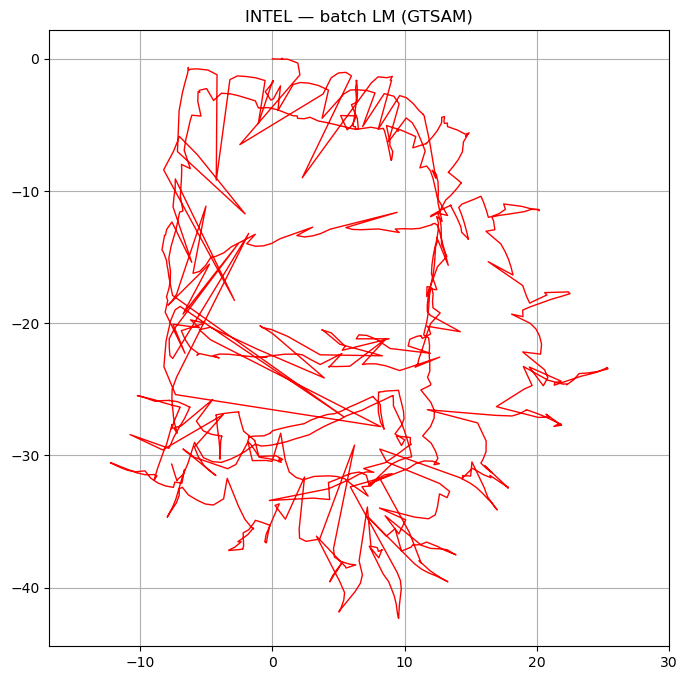

In [2]:
import gtsam
import matplotlib.pyplot as plt

nodes, edges = load_2d_g2o(G2O_PATH)

graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

# Anchor the first pose (replaces the +1e6*I trick on H[0:3, 0:3])
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6, 1e-6, 1e-8]))
graph.add(gtsam.PriorFactorPose2(
    nodes[0]['id'],
    gtsam.Pose2(*nodes[0]['state']),
    prior_noise,
))

# Initial guesses from the g2o file
for n in nodes:
    initial.insert(n['id'], gtsam.Pose2(*n['state']))

# One BetweenFactor per edge — replaces the per-edge A_ij, B_ij, info assembly.
# Gaussian.Information() converts an information matrix to a noise model.
for e in edges:
    noise = gtsam.noiseModel.Gaussian.Information(e['info'])
    graph.add(gtsam.BetweenFactorPose2(
        e['id1'], e['id2'],
        gtsam.Pose2(*e['meas']),
        noise,
    ))

params = gtsam.LevenbergMarquardtParams()
params.setVerbosityLM("SUMMARY")  # per-iteration error, analogous to dx_norm print
result = gtsam.LevenbergMarquardtOptimizer(graph, initial, params).optimize()

xs = [result.atPose2(n['id']).x() for n in nodes]
ys = [result.atPose2(n['id']).y() for n in nodes]
plt.figure(figsize=(8, 8))
plt.plot(xs, ys, color="red", linewidth=1)
plt.title("INTEL — batch LM (GTSAM)")
plt.axis("equal"); plt.grid(True); plt.show()


### 11.2 Incremental iSAM2 with live plotting

iSAM2 is overkill for a one-shot batch problem — its incremental bookkeeping pays off only when measurements arrive over time. This cell *simulates* the online case by feeding edges to iSAM2 one at a time and re-plotting after each update, so you can watch the trajectory snap into shape as loop closures fire.

The interesting moments aren't the odometry edges (those just extend the trajectory pose by pose). The drama is on loop closures: an edge connects pose $i$ back to pose $j$, and the whole middle section snaps into a more consistent shape as iSAM2 re-linearizes the affected sub-tree.

* `PLOT_EVERY = 1` makes it slow but dramatic; `5–20` is usually a good speed for INTEL/MITb.
* `plt.pause(0.001)` just yields to the GUI event loop; bump to `0.05` to slow it down.


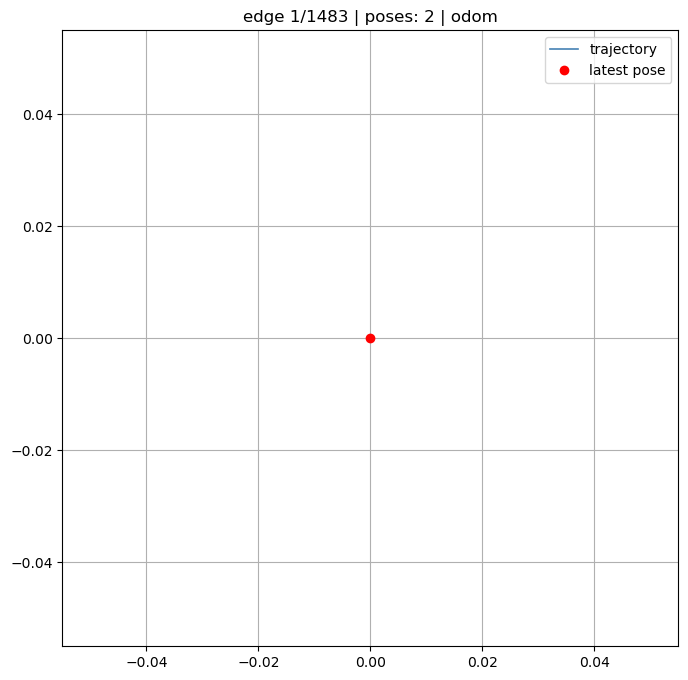

In [3]:
import gtsam
import matplotlib.pyplot as plt

nodes, edges = load_2d_g2o(G2O_PATH)
node_lookup = {n['id']: n for n in nodes}

# iSAM2 setup
isam_params = gtsam.ISAM2Params()
isam_params.setRelinearizeThreshold(0.01)  # tau_relin from §9.5 step 4
isam_params.relinearizeSkip = 1
isam = gtsam.ISAM2(isam_params)

prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6, 1e-6, 1e-8]))
added_poses = set()

# Live-plot setup
plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))
(traj_line,) = ax.plot([], [], '-', color='steelblue', lw=1.2, label='trajectory')
(latest_pt,) = ax.plot([], [], 'o', color='red', ms=6, label='latest pose')
loop_segments = []
ax.set_aspect('equal'); ax.grid(True); ax.legend(loc='upper right')
title = ax.set_title("")

PLOT_EVERY = 5  # 1 = max drama, higher = faster


def is_odometry(edge):
    return abs(edge['id1'] - edge['id2']) == 1


for idx, e in enumerate(edges):
    new_factors = gtsam.NonlinearFactorGraph()
    new_values = gtsam.Values()

    # Anchor the very first pose the first time we touch it
    if nodes[0]['id'] not in added_poses:
        first = nodes[0]
        new_factors.add(gtsam.PriorFactorPose2(
            first['id'], gtsam.Pose2(*first['state']), prior_noise,
        ))
        new_values.insert(first['id'], gtsam.Pose2(*first['state']))
        added_poses.add(first['id'])

    # Insert endpoints we haven't seen yet, with their g2o initial guess
    for pid in (e['id1'], e['id2']):
        if pid not in added_poses:
            s = node_lookup[pid]['state']
            new_values.insert(pid, gtsam.Pose2(*s))
            added_poses.add(pid)

    noise = gtsam.noiseModel.Gaussian.Information(e['info'])
    new_factors.add(gtsam.BetweenFactorPose2(
        e['id1'], e['id2'], gtsam.Pose2(*e['meas']), noise,
    ))
    isam.update(new_factors, new_values)

    # Visualize current estimate
    if idx % PLOT_EVERY == 0 or idx == len(edges) - 1:
        est = isam.calculateEstimate()
        ids_sorted = sorted(added_poses)
        xs = [est.atPose2(i).x() for i in ids_sorted]
        ys = [est.atPose2(i).y() for i in ids_sorted]
        traj_line.set_data(xs, ys)
        latest_pt.set_data([xs[-1]], [ys[-1]])

        # Draw loop closures as faint chords so you can see them "pull" the graph
        if not is_odometry(e):
            p1 = est.atPose2(e['id1']); p2 = est.atPose2(e['id2'])
            seg, = ax.plot(
                [p1.x(), p2.x()], [p1.y(), p2.y()],
                '-', color='orange', alpha=0.4, lw=0.8,
            )
            loop_segments.append(seg)

        ax.relim(); ax.autoscale_view()
        title.set_text(
            f"edge {idx + 1}/{len(edges)} | poses: {len(added_poses)} "
            f"| {'LOOP' if not is_odometry(e) else 'odom'}"
        )
        fig.canvas.draw_idle()
        plt.pause(0.001)

plt.ioff(); plt.show()


### 11.3 Toy 10-pose example: per-step iSAM2 with live plots

The INTEL run above is realistic but visually busy. This toy problem — 10 poses, odometry $z_{i,i+1} = (1.0,\ 0,\ 0.01)$, one loop closure $z_{6,9} = (3.0,\ 0.10,\ 0)$ — keeps $N$ small enough that you can watch the trajectory snap into shape after every single factor is added.

The cell below feeds factors to iSAM2 one at a time and re-plots after each `update()`. Watch the moment the loop closure $X_6 \!\to\! X_9$ fires: only the suffix $X_7, X_8, X_9$ moves noticeably, because the prior + odometry chain makes it cheaper to bend the late portion of the trajectory than to drag the whole thing backward — exactly the "affected sub-tree" of §9.5 step 2.


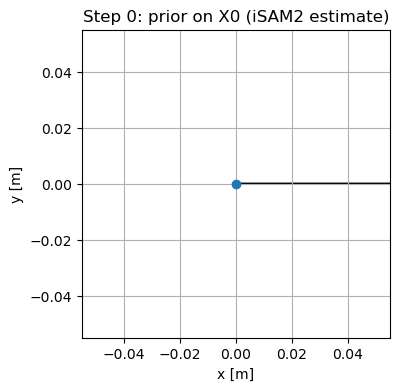

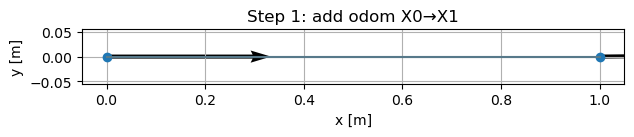

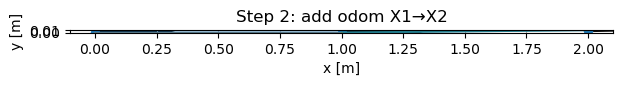

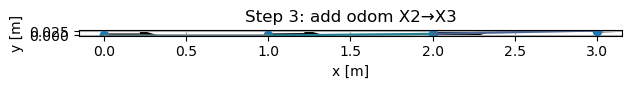

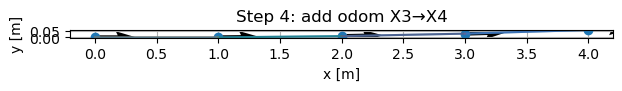

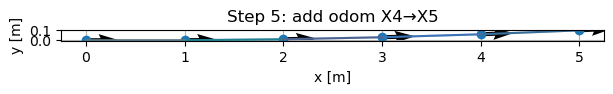

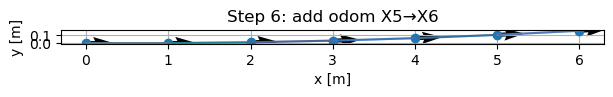

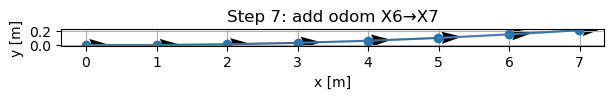

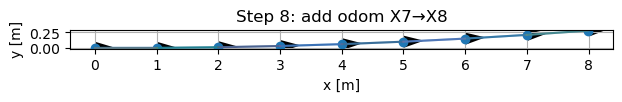

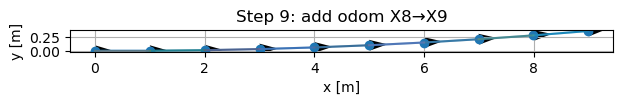

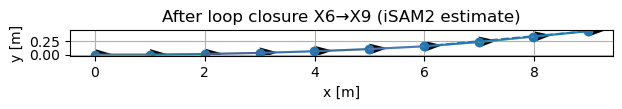

Final iSAM2 poses:
X0: x= 0.0000, y= 0.0000, theta= 0.0000 rad
X1: x= 1.0000, y= 0.0000, theta= 0.0100 rad
X2: x= 2.0000, y= 0.0100, theta= 0.0200 rad
X3: x= 2.9998, y= 0.0300, theta= 0.0300 rad
X4: x= 3.9993, y= 0.0600, theta= 0.0400 rad
X5: x= 4.9985, y= 0.1000, theta= 0.0500 rad
X6: x= 5.9973, y= 0.1500, theta= 0.0600 rad
X7: x= 6.9938, y= 0.2284, theta= 0.0800 rad
X8: x= 7.9890, y= 0.3268, theta= 0.0814 rad
X9: x= 8.9840, y= 0.4266, theta= 0.0643 rad


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gtsam
from gtsam import symbol


def sigmas_from_information(diag_info):
    return 1.0 / np.sqrt(np.asarray(diag_info, dtype=float))


def values_to_xytheta(values, keys):
    xs, ys, th = [], [], []
    for k in keys:
        p = values.atPose2(k)
        xs.append(p.x()); ys.append(p.y()); th.append(p.theta())
    return np.array(xs), np.array(ys), np.array(th)


def plot_step(values, odom_edges, loop_edges, title):
    keys = sorted(values.keys())
    xs, ys, th = values_to_xytheta(values, keys)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(xs, ys, marker="o", linestyle="-")
    ax.quiver(xs, ys, np.cos(th), np.sin(th),
              angles="xy", scale_units="xy", scale=3)

    def draw(edges, style, alpha):
        for a, b in edges:
            pa = values.atPose2(a); pb = values.atPose2(b)
            ax.plot([pa.x(), pb.x()], [pa.y(), pb.y()], style, alpha=alpha)

    draw(odom_edges, "-", 0.25)
    draw(loop_edges, "--", 0.95)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True); ax.set_title(title)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    plt.show()


N = 10
def X(i): return symbol("x", i)

# Information -> sigma conversion (diag(400) -> 0.05, diag(2500) -> 0.02, diag(1e6) -> 0.001)
noise_odom = gtsam.noiseModel.Diagonal.Sigmas(sigmas_from_information([400, 400, 400]))
noise_loop = gtsam.noiseModel.Diagonal.Sigmas(sigmas_from_information([2500, 2500, 2500]))
noise_0    = gtsam.noiseModel.Diagonal.Sigmas(sigmas_from_information([1e6, 1e6, 1e6]))

z0          = gtsam.Pose2(0.0, 0.0, 0.0)
z_odom      = gtsam.Pose2(1.0, 0.0, 0.01)
z_loop_6_9  = gtsam.Pose2(3.0, 0.10, 0.0)

isam_params = gtsam.ISAM2Params()
isam_params.setRelinearizeThreshold(0.01)
isam_params.relinearizeSkip = 1
isam = gtsam.ISAM2(isam_params)

odom_edges, loop_edges = [], []

# Step 0: prior on X0
new_factors = gtsam.NonlinearFactorGraph()
new_values  = gtsam.Values()
new_factors.add(gtsam.PriorFactorPose2(X(0), z0, noise_0))
new_values.insert(X(0), z0)
isam.update(new_factors, new_values)
plot_step(isam.calculateEstimate(), odom_edges, loop_edges,
          "Step 0: prior on X0 (iSAM2 estimate)")

# Steps 1..9: add odometry one factor at a time
for i in range(N - 1):
    new_factors = gtsam.NonlinearFactorGraph()
    new_values  = gtsam.Values()
    new_factors.add(gtsam.BetweenFactorPose2(X(i), X(i + 1), z_odom, noise_odom))
    odom_edges.append((X(i), X(i + 1)))
    guess_next = isam.calculateEstimate().atPose2(X(i)).compose(z_odom)
    new_values.insert(X(i + 1), guess_next)
    isam.update(new_factors, new_values)
    plot_step(isam.calculateEstimate(), odom_edges, loop_edges,
              f"Step {i + 1}: add odom X{i}→X{i + 1}")

# Loop closure 6 -> 9 — the suffix X7, X8, X9 should move noticeably
new_factors = gtsam.NonlinearFactorGraph()
new_factors.add(gtsam.BetweenFactorPose2(X(6), X(9), z_loop_6_9, noise_loop))
loop_edges.append((X(6), X(9)))
isam.update(new_factors, gtsam.Values())
plot_step(isam.calculateEstimate(), odom_edges, loop_edges,
          "After loop closure X6→X9 (iSAM2 estimate)")

print("Final iSAM2 poses:")
final = isam.calculateEstimate()
for i in range(N):
    p = final.atPose2(X(i))
    print(f"X{i}: x={p.x(): .4f}, y={p.y(): .4f}, theta={p.theta(): .4f} rad")


## Summary

| concept | meaning |
|---|---|
| **factor graph** | bipartite graph with variable nodes and factor nodes; each factor is a measurement-induced cost on a small subset of variables |
| **MAP estimate** | $\arg\min_\theta \sum_k \tfrac12 \|f_k(\theta_{S_k})\|^2_{\Omega_k}$ — same NLS recipe as in pose-graph SLAM |
| **information form** $\Lambda$ | $\Lambda = \Sigma^{-1}$; factors compose additively; sparsity = conditional independence |
| **assembly** $J^\top \Omega J$ | how blocks of $\Lambda$ are *built* from each factor's Jacobian — once per Gauss-Newton iteration |
| **Schur complement** | $\Lambda_A^{\text{marg}} = \Lambda_{AA} - \Lambda_{AB}\Lambda_{BB}^{-1}\Lambda_{BA}$; the operation behind elimination, marginalization, conditioning, BA $\to$ pose graph |
| **fill-in** | new direct couplings created when a variable is eliminated; the cost-driver of factorization |
| **eliminate** | factor the joint as $p(x_B \mid x_A, x_C) \cdot p(x_A, x_C)$; the second piece is the Schur-complement update |
| **clique** | (graph) mutually connected set; (Bayes tree) a node storing one elimination's conditional $(R, S, d)$ |
| **back-substitution** | tree traversal root → leaves that solves $\Delta\chi$ from the stored $(R, S, d)$ — replaces `np.linalg.solve(H, b)` |
| **ordering** | sequence of eliminations; chosen by MMD / COLAMD to keep separators small; same answer regardless of order |
| **Bayes tree** | tree of cliques recording the elimination factorization |
| **iSAM2 (batch)** | a clean way to write Gauss-Newton on the tree; same arithmetic as your notebook |
| **iSAM2 (online)** | when a new factor arrives, only redo cliques on the path from the affected variable to the root |
| **fixed-lag smoother** | bounded-memory back-end; marginalizes old poses via Schur and replaces them with a dense boundary prior |
| **hybrid back-end** | smoother + pose graph in parallel; loop closures go to the pose graph because the smoother has dropped the old endpoints |
